# Urban Livability Evaluation with Multimodal Deep Learning
## A Step-by-Step Tutorial

This tutorial walks through the end-to-end pipeline from:

> **Zhou, W., Persello, C., Ming, D., Wang, S., & Stein, A. (2026).**
> *A Transformer-based Multi-task Deep Learning Model for Urban Livability Evaluation
> by Fusing Remote Sensing and Textual Geospatial Data.*
> Remote Sensing of Environment, 334, 115232.
> [https://doi.org/10.1016/j.rse.2026.115232](https://doi.org/10.1016/j.rse.2026.115232)

The model fine-tunes a **improved MMBT (Multimodal Bitransformer)** for **multi-task regression** of urban
livability across **6 aspects** by fusing four types of geospatial data:

| Modality | Type | Description |
|---|---|---|
| 🛰️ RS Image | Remote sensing | High-resolution (0.25 m/px) RGB satellite imagery |
| 🏔️ DSM Image | Remote sensing | Digital Surface Model — building/terrain heights |
| 🌙 NLRS Image | Remote sensing | Night-Light Remote Sensing — socioeconomic proxy |
| 📍 POI Text | Textual | Point-of-Interest category descriptions |

Parts of the code are adapted from the HuggingFace
[`run_mmimdb.py`](https://github.com/huggingface/transformers/blob/8ea412a86faa8e9edeeb6b5c46b08def06aa03ea/examples/research_projects/mm-imdb/run_mmimdb.py)
script for the MMBT model.

---
**What can you learn**

Helping your own research and serving as educational materials.

Research Question --> Data preparing --> Method development --> Results analysis --> Discussion --> Conclusion

---
**Tutorial Sections**

1. [Research Background](#1.-Research-Background-and-Motivation)
2. [Setup & Authentication](#2.-Setup-and-Authentication)
3. [Dataset Description](#3.-Dataset-Description)
4. [Model Architecture](#4.-Model-Architecture)
5. [Experiment Hyperparameters](#5.-Experiment-Hyperparameters)
6. [Loading the Dataset](#6.-Loading-the-Dataset)
7. [Training the TMTMR Model](#7.-Training-the-TMTMR-Model)
8. [Evaluation & Results](#8.-Evaluation-and-Results)
9. [Cross-Modal Attention Analysis](#9.-Cross-Modal-Attention-Analysis)
10. [Full Grad-CAM Saliency Visualization](#10.-Full-Grad-CAM-Saliency-Visualization)


## 1. Research Background and Motivation

### What is Urban Livability?

Urban livability captures the overall quality of life in a city. It is determined by a complex
interplay of environmental, social, economic, and physical factors. Livability assessments help
policymakers design interventions that make cities healthier, safer, and more inclusive.

### The Challenge of Traditional Assessment

Conventional livability indices (e.g., the Dutch *Leefbaarometer*) are constructed by:
1. Collecting survey responses from thousands of residents,
2. Selecting indicators (e.g., crime rates, green-space coverage, housing density),
3. Assigning expert-defined weights to each indicator,
4. Aggregating into domain scores.

This process is **labour-intensive, expensive, and hard to replicate** at scale or in real time.

### Why Deep Learning + Geospatial Data?

The proliferation of publicly available geospatial datasets (satellite imagery, DSM, night-lights,
OpenStreetMap POIs) enables a data-driven alternative. Deep learning models can:

- Extract rich spatial and semantic features automatically,
- Handle multiple data modalities simultaneously,
- Generalise across spatial locations,
- Produce predictions at fine spatial granularity.

### Key Contributions of the Paper

1. **TMTMR model** — a Transformer-based Multi-task Multimodal Regression architecture that
   simultaneously predicts 6 livability domain scores.
2. **Four-modality fusion** — RS imagery, DSM, night-light, and POI text are combined inside a
   single unified Transformer.
3. **Multi-task learning** — shared representations leverage correlations among livability domains.
4. **Modality ablation study** — reveals the contribution of each modality:
   RS images > Night-light > DSM > POI text.
5. **Open dataset** — the training/test data are publicly released on HuggingFace 🤗.


## 2. Setup and Authentication

Before running the training or evaluation pipeline you need to:

1. **Install dependencies** (see `requirements.txt`).
2. **Authenticate with HuggingFace** — the dataset and pre-trained model are hosted on 🤗 Hub.
   - The **model weights** (`Vinjou/Multimodal_urban_livability_evaluation_model`) are **fully public** and require no authentication.
   - The **dataset** (`Vinjou/Multimodal_urban_livability_evaluation_dataset`) is **public but gated** (licensed under CC-BY-NC-4.0).
     You must **accept the access conditions** on the dataset page before your token will work:
     
     👉 https://huggingface.co/datasets/Vinjou/Multimodal_urban_livability_evaluation_dataset
3. **GPU** (recommended) — training is significantly faster on CUDA. The code auto-detects the
   device. CPU inference is supported for evaluation.

Run the cells below to complete the setup.


## 🔐 Hugging Face Authentication (Required for Dataset Access)

**Important**: The dataset is **gated** — it is publicly available but requires you to first accept
the license terms on the Hugging Face website. Authentication **cannot be skipped**.

> ⚠️ **Step 1 — Accept dataset terms (one-time, required)**  
> Visit the dataset page and click **"Access repository"** to accept the CC-BY-NC-4.0 license:
> 👉 https://huggingface.co/datasets/Vinjou/Multimodal_urban_livability_evaluation_dataset  
> Without this step, any token will be rejected with a 403 error.
![HF Access Token](HF_accesstoken.png)
> ⚠️ **Step 2 — Creating an access token to use this dataset**  
> Visit the access token page and click **"Creat new token"** :
> 👉 https://huggingface.co/settings/tokens  

The **model weights** (`Vinjou/Multimodal_urban_livability_evaluation_model`) are fully public and
will be downloaded automatically without any token.

---
### Method 1: Pass Token Directly in Code

If the above methods don't work, you can pass the token directly in the `load_examples` function.
Find the `load_examples` function and modify the `load_dataset` call:

```python
hf_dataset_dict = load_dataset("Vinjou/Multimodal_urban_livability_evaluation_dataset", token="your_token_here")
```

Replace `"your_token_here"` with your actual Hugging Face token.
### Method 2: Using Hugging Face CLI (Recommended)

Run the following commands in a terminal before starting Jupyter:

```bash
# Install huggingface_hub (if not already installed)
pip install huggingface_hub

# Login to Hugging Face
huggingface-cli login
```

When prompted, enter your Hugging Face token. You can generate a token (read access is sufficient) at:
- https://huggingface.co/settings/tokens

### Method 3: Set Token in Notebook

If you cannot use CLI login (e.g., on web platforms), run the cell below to set your token directly.



In [ ]:
import os
os.environ['HF_TOKEN'] = 'your token here'  # Replace with your actual token


In [2]:
# Install huggingface_hub if not already installed
import subprocess
import sys

try:
    import huggingface_hub
    print("✓ huggingface_hub is already installed")
except ImportError:
    print("Installing huggingface_hub...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "huggingface_hub"])
    print("✓ huggingface_hub installed successfully")

# Check if already logged in
from huggingface_hub import HfFolder
token = HfFolder.get_token()

if token:
    print("✓ Hugging Face token found. You are already logged in.")
    print(f"  Token starts with: {token[:10]}...")
else:
    print("⚠️  No Hugging Face token found.")
    print("Please login using one of the following methods:")
    print("  1. Run in terminal: huggingface-cli login")
    print("  2. Or set token below:")
    print()
    print("# Uncomment and set your token:")
    print("# import os")
    print("# os.environ['HF_TOKEN'] = 'your_token_here'")

✓ huggingface_hub is already installed
✓ Hugging Face token found. You are already logged in.
  Token starts with: hf_TbuENcs...


In [3]:
# textBert_utils.py is imported as a module in later cells, not run directly
# The file exists in the same directory as this notebook
print("textBert_utils.py is available and will be imported as needed")

textBert_utils.py is available and will be imported as needed


In [4]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.    
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

No GPU available, using the CPU instead.


## Install Huggingface Library

These should have been installed during your environment set-up; you only need to run these cells in I-GUIDE Platform.

## Import Required Modules

In [5]:
import sys, os

project_dir = "/Multimodal-multi-task-urban-livability-evaluation"

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)
print("Using project directory:", project_dir)

from textBert_utils import set_seed

Using project directory: /Multimodal-multi-task-urban-livability-evaluation


2026-08-03 20:38:54.720753: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-03 20:38:57.341628: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [6]:
from MMBT_liva.image_liva import ImageEncoderDenseNet
from MMBT_liva.mmbt_config_liva import MMBTConfig
from MMBT_liva.mmbt_liva import MMBTForClassification


## 3. Dataset Description

### Study Area — 13 Dutch Neighbourhoods

The dataset covers **13 areas across the Netherlands**, spanning dense urban centres, mid-size
cities, and suburban districts. The target labels come from the Dutch *Leefbaarometer* — a
nationally validated livability index published by the Dutch Ministry of the Interior.

Each geographic unit (neighbourhood polygon) is labelled with **6 livability scores** (range ≈ 0–1):

| Code | Dutch Name | English Name | Description |
|---|---|---|---|
| **LBM** | Leefbaarheid | **Overall Livability** | Composite index |
| **FYS** | Fysieke Omgeving | **Physical Environment** | Green space, noise, air quality |
| **ONV** | Overlast & Onveiligheid | **Nuisance & Insecurity** | Crime, disorder |
| **SOC** | Sociale Samenhang | **Social Cohesion** | Community ties |
| **VRZ** | Voorzieningen | **Amenities** | Shops, schools, healthcare |
| **WON** | Woningvoorraad | **Housing Quality** | Building age, density, type |

### Input Modalities per Sample

Each neighbourhood patch is represented by a set of image tiles and a POI text string:

```
sample = {
    "rs_image":   PIL.Image (224×224, RGB)        ← satellite RGB
    "dsm_image":  PIL.Image (224×224, grayscale)  ← height map
    "giu_image":  PIL.Image (224×224, grayscale)  ← night-light
    "text":       str                              ← POI category list
    "lbm": float, "fys": float, "onv": float,
    "soc": float, "vrz": float, "won": float
}
```

### Dataset Split

| Split | Areas | Approx. Samples |
|---|---|---|
| Train | 9 areas | 29308 |
| Validation | 9 areas | 9253 |
| Test (full) | 4 areas | 13440 |
| Test (Beesel subset) | Beesel | 16 samples |

The dataset is publicly available on HuggingFace:
🤗 [Vinjou/Multimodal_urban_livability_evaluation_dataset](https://huggingface.co/datasets/Vinjou/Multimodal_urban_livability_evaluation_dataset)


In [7]:
from MMBT_liva.mmbt_utils_liva_0318 import JsonlDataset, get_image_transforms, get_labels, load_examples, collate_fn, get_multiclass_labels, get_multiclass_criterion 

In [8]:
from datasets import load_dataset
import os
from torch.utils.data import Dataset
import torch
from MMBT_liva.mmbt_utils_liva_0318 import get_image_transforms, get_image_transforms_gray, get_image_transforms_giu

class HFDatasetWrapper(Dataset):
    def __init__(self, hf_dataset, tokenizer, transforms, transforms_gray, transforms_giu, max_seq_length):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.n_classes = 6
        self.max_seq_length = max_seq_length
        self.transforms = transforms
        self.transforms_gray = transforms_gray
        self.transforms_giu = transforms_giu

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        item = self.dataset[index]
        
        # Text encoding
        sentence = torch.LongTensor(self.tokenizer.encode(item["text"], add_special_tokens=True))
        start_token, sentence, end_token = sentence[0], sentence[1:-1], sentence[-1]
        sentence = sentence[:self.max_seq_length]

        # Labels
        label = torch.zeros(self.n_classes)
        label[0] = float(item["lbm"])
        label[1] = float(item["fys"])
        label[2] = float(item["onv"])
        label[3] = float(item["soc"])
        label[4] = float(item["vrz"])
        label[5] = float(item["won"])

        # Images from HF are already PIL images
        rs = item["rs_image"].convert("RGB")
        rs = self.transforms(rs)

        dsm = item["dsm_image"].convert("RGB")
        dsm = self.transforms_gray(dsm)
        
        giu = item["giu_image"].convert("RGB")
        giu = self.transforms_giu(giu)

        # Concatenate 3 images along channel dimension (3+3+3 = 9 channels)
        image_3 = torch.cat((rs, dsm, giu), dim=0)
        
        return {
            "image_start_token": start_token,
            "image_end_token": end_token,
            "sentence": sentence,
            "image": image_3,
            "label": label,
        }

def load_examples(tokenizer, wandb_config, evaluate=False, test=False, **kwargs):
    """Overriding load_examples to use Hugging Face dataset"""
    print(f"Loading dataset 'Vinjou/Multimodal_urban_livability_evaluation_dataset' from Hugging Face... (evaluate={evaluate}, test={test})")
    # Try to load dataset with token if available
    try:
        # First, try with token from environment or Hugging Face cache
        import os
        from huggingface_hub import HfFolder
        token = os.environ.get("HF_TOKEN") or HfFolder.get_token()
        
        if not token:
            raise RuntimeError("HF token missing. Please set HF_TOKEN environment variable or run huggingface-cli login.")
        
        # Load dataset with token
        hf_dataset_dict = load_dataset("Vinjou/Multimodal_urban_livability_evaluation_dataset", token=token)
    except Exception as e:
        # If loading fails, provide helpful error message
        error_msg = str(e)
        if "Unauthorized" in error_msg or "token" in error_msg.lower():
            print("❌ Authentication required to access the dataset.")
            print("Please login to Hugging Face using one of the following methods:")
            print("  1. Run: huggingface-cli login")
            print("  2. Or set environment variable: export HF_TOKEN=your_token")
            print("  3. Or pass token directly: load_dataset(..., token=your_token)")
        raise
    
    if evaluate and not test:
        hf_dataset = hf_dataset_dict["validation"]
    elif evaluate and test:
        hf_dataset = hf_dataset_dict["test"]
        # Optional: filter test set to only IDs (or img names) listed in a local JSON/JSONL file (e.g. Livability_test_Beesel.json)
        test_subset_json = getattr(wandb_config, "test_subset_json", "") or ""
        if test_subset_json and os.path.exists(test_subset_json):
            import json
            subset_ids = set()
            subset_imgs = set()
            with open(test_subset_json) as f:
                for line in f:
                    line = line.strip()
                    if line:
                        row = json.loads(line)
                        subset_ids.add(row["id"])
                        if "img" in row:
                            subset_imgs.add(row["img"])
            if "id" in hf_dataset.features:
                hf_dataset = hf_dataset.filter(lambda x: x["id"] in subset_ids)
                print(f"  Filtered test set to {len(hf_dataset)} samples (subset from {test_subset_json})")
            elif "img" in hf_dataset.features and subset_imgs:
                hf_dataset = hf_dataset.filter(lambda x: x["img"] in subset_imgs)
                print(f"  Filtered test set to {len(hf_dataset)} samples by 'img' (subset from {test_subset_json})")
            else:
                print(f"  Warning: test_subset_json set but dataset has no 'id' or 'img' column; using full test set.")
        
    else:
        hf_dataset = hf_dataset_dict["train"]

    img_transforms = get_image_transforms()
    img_transforms_gray = get_image_transforms_gray()
    img_transforms_giu = get_image_transforms_giu()

    dataset = HFDatasetWrapper(
        hf_dataset, 
        tokenizer, 
        img_transforms, 
        img_transforms_gray, 
        img_transforms_giu, 
        wandb_config.max_seq_length - wandb_config.num_image_embeds - 2
    )
    return dataset

def hf_collate_fn(batch):
    """
    Specify batching for the Hugging Face dataset
    """
    lens = [len(row["sentence"]) for row in batch]
    bsz, max_seq_len = len(batch), max(lens)

    mask_tensor = torch.zeros(bsz, max_seq_len, dtype=torch.long)
    text_tensor = torch.zeros(bsz, max_seq_len, dtype=torch.long)

    for i_batch, (input_row, length) in enumerate(zip(batch, lens)):
        text_tensor[i_batch, :length] = input_row["sentence"]
        mask_tensor[i_batch, :length] = 1

    img_tensor = torch.stack([row["image"] for row in batch])
    tgt_tensor = torch.stack([row["label"] for row in batch])
    img_start_token = torch.stack([row["image_start_token"] for row in batch])
    img_end_token = torch.stack([row["image_end_token"] for row in batch])

    return {
        "sentence": text_tensor,
        "attention_mask": mask_tensor,
        "image": img_tensor,
        "image_start_token": img_start_token,
        "image_end_token": img_end_token,
        "label": tgt_tensor
    }


In [9]:
import argparse

In [10]:
import glob
import logging
import random
import json
import os
from collections import Counter
import numpy as np
from matplotlib.pyplot import imshow

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

In [11]:
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, multilabel_confusion_matrix, hamming_loss, classification_report
# Disable Jupyter widgets for tqdm to avoid version compatibility warnings
import os
os.environ['TQDM_DISABLE'] = '1'

from tqdm import tqdm, trange

from transformers import (
    WEIGHTS_NAME,
    AutoConfig,
    AutoModel,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

try:
    from torch.utils.tensorboard import SummaryWriter
except ImportError:
    from tensorboardX import SummaryWriter

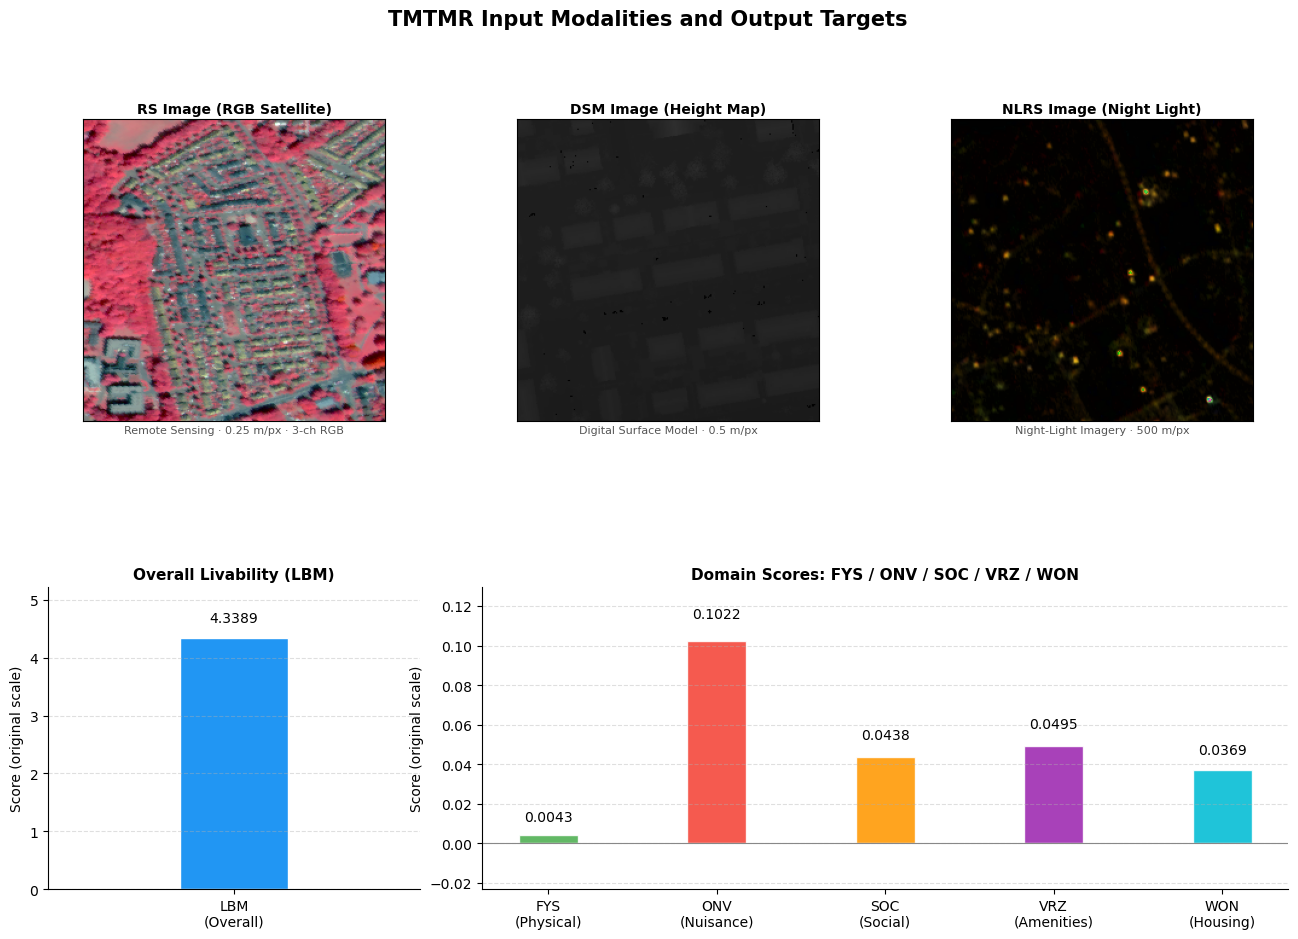

POI Text Input (sample)
recycling_glass  restaurant Restaurant Kampulanschool
Julianaschoolmuseum Museum Bronbeek en Koninklijk tehuis voor
Militairenpost_box


In [12]:
"""
Visualise the four input modalities and the six livability target dimensions.
Uses real samples from the Hugging Face dataset (Vinjou/Multimodal_urban_livability_evaluation_dataset).

Layout:
  Row 1 : RS image | DSM image | NLRS image
  Row 2 : LBM chart (left)  |  FYS/ONV/SOC/VRZ/WON chart (right)
  POI text is printed below the figure as plain cell output.
"""
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import textwrap, random, os
from datasets import load_dataset

# ── Load a small slice from HuggingFace (only 20 rows to avoid slow full download) ──
try:
    from huggingface_hub import HfFolder
    token = os.environ.get("HF_TOKEN") or HfFolder.get_token()
    if not token:
        raise RuntimeError("HF token missing.")
    # split="train[:20]" downloads only the first 20 samples — much faster than the full dataset
    _preview = load_dataset(
        "Vinjou/Multimodal_urban_livability_evaluation_dataset",
        split="train[:3]",
        token=token,
    )
    # pick a sample with non-trivial POI text
    candidates = [s for s in _preview
                  if isinstance(s["text"], str) and s["text"].strip() not in ("", "Null")
                  and len(s["text"].strip()) > 30]
    sample = random.choice(candidates) if candidates else _preview[0]
except Exception as e:
    raise RuntimeError(f"Cannot load dataset: {e}") from e

# ── Shared style constants ────────────────────────────────────────────────────
BAR_W     = 0.35
TICK_FS   = 10
ANNOT_FS  = 10
YLABEL_FS = 10
TITLE_FS  = 11

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle("TMTMR Input Modalities and Output Targets",
             fontsize=15, fontweight="bold", y=0.99)

gs = gridspec.GridSpec(2, 6, figure=fig,
                        height_ratios=[3, 3],
                        hspace=0.55, wspace=0.4)

# ── Row 0: three images (original aspect ratio) ──────────────────────────────
img_specs = [
    ("rs_image",  "RS Image (RGB Satellite)", "Remote Sensing · 0.25 m/px · 3-ch RGB",  None),
    ("dsm_image", "DSM Image (Height Map)",   "Digital Surface Model · 0.5 m/px",        "terrain"),
    ("giu_image", "NLRS Image (Night Light)", "Night-Light Imagery · 500 m/px",           "hot"),
]
for col, (key, title, desc, cmap) in enumerate(img_specs):
    ax = fig.add_subplot(gs[0, col*2 : col*2+2])
    img = sample[key]
    if hasattr(img, "convert") and img.mode != "RGB":
        img = img.convert("RGB")
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=4)
    ax.set_xlabel(desc, fontsize=8, color="#555", labelpad=3)
    ax.set_xticks([]); ax.set_yticks([])

# ── Helper: annotate bar value ────────────────────────────────────────────────
def annotate(ax, bar_obj, value):
    x   = bar_obj.get_x() + bar_obj.get_width() / 2
    off = abs(value) * 0.05 + 0.005
    va  = "bottom" if value >= 0 else "top"
    y   = value + off if value >= 0 else value - off
    ax.text(x, y, f"{value:.4f}", ha="center", va=va, fontsize=ANNOT_FS)

# ── Row 1 left: LBM ──────────────────────────────────────────────────────────
lbm_val = float(sample["lbm"])
ax_lbm  = fig.add_subplot(gs[1, :2])
(b,) = ax_lbm.bar([0], [lbm_val], color="#2196F3", edgecolor="white", width=BAR_W)
annotate(ax_lbm, b, lbm_val)
ax_lbm.set_xticks([0])
ax_lbm.set_xticklabels(["LBM\n(Overall)"], fontsize=TICK_FS)
ax_lbm.tick_params(axis="y", labelsize=TICK_FS)
ax_lbm.set_xlim(-0.6, 0.6)
ax_lbm.set_ylim(0, lbm_val + abs(lbm_val)*0.18 + 0.1)
ax_lbm.set_title("Overall Livability (LBM)", fontsize=TITLE_FS, fontweight="bold")
ax_lbm.set_ylabel("Score (original scale)", fontsize=YLABEL_FS)
ax_lbm.spines[["top","right"]].set_visible(False)
ax_lbm.grid(axis="y", linestyle="--", alpha=0.4)

# ── Row 1 right: 5 domain scores ─────────────────────────────────────────────
other_vals = {
    "FYS\n(Physical)":  float(sample["fys"]),
    "ONV\n(Nuisance)":  float(sample["onv"]),
    "SOC\n(Social)":    float(sample["soc"]),
    "VRZ\n(Amenities)": float(sample["vrz"]),
    "WON\n(Housing)":   float(sample["won"]),
}
other_colors = ["#4CAF50","#F44336","#FF9800","#9C27B0","#00BCD4"]
ax_5    = fig.add_subplot(gs[1, 2:])
labels5 = list(other_vals.keys())
vals5   = list(other_vals.values())
bars5   = ax_5.bar(labels5, vals5, color=other_colors,
                    edgecolor="white", width=BAR_W, alpha=0.88)
for b, v in zip(bars5, vals5):
    annotate(ax_5, b, v)
ax_5.axhline(0, color="#888", linewidth=0.8)
ax_5.tick_params(axis="x", labelsize=TICK_FS)
ax_5.tick_params(axis="y", labelsize=TICK_FS)
ax_5.set_title("Domain Scores: FYS / ONV / SOC / VRZ / WON",
               fontsize=TITLE_FS, fontweight="bold")
ax_5.set_ylabel("Score (original scale)", fontsize=YLABEL_FS)
ax_5.spines[["top","right"]].set_visible(False)
ax_5.grid(axis="y", linestyle="--", alpha=0.4)
y_min = min(vals5); y_max = max(vals5)
span  = max(abs(y_max - y_min), 0.05)
ax_5.set_ylim(y_min - span*0.28, y_max + span*0.28)

plt.savefig("dataset_overview.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Print POI text as cell output ────────────────────────────────────────────
raw_text = sample["text"] if isinstance(sample["text"], str) else str(sample["text"])
print("=" * 70)
print("POI Text Input (sample)")
print("=" * 70)
for para in raw_text.split("\n"):
    for line in textwrap.wrap(para, width=68) or [""]:
        print(line)
print("=" * 70)


## 4. Model Architecture

### Overview

This study proposes the **Transformer-based Multi-task Multimodal Regression (TMTMR)** model for simultaneously evaluating urban livability across **six domain-specific scores** from four types of geospatial data. The architecture is built upon the [MMBT (Multimodal Bitransformer)](https://arxiv.org/abs/1909.02950) framework (Kiela et al., 2019), extended for **regression** and **multi-task learning**.

---

### 4.1 Image Branch — DenseNet-121 Encoder

Each of the three image modalities (**RS**, **DSM**, **NLRS**) is processed **independently** by a shared **DenseNet-121** backbone pre-trained on ImageNet:

```
Input image  →  B × 3 × 224 × 224
                ↓  DenseNet-121 feature extractor (conv + dense blocks)
                B × 1024 × 7 × 7
                ↓  ReLU + AdaptiveAvgPool2d (3 × 1)
                B × 1024 × 3
                ↓  Transpose
                B × 3 × 1024        ← 3 spatial patch embeddings per image
```

The three streams are then **concatenated** along the sequence axis:

```
RS   → B × 3 × 1024
DSM  → B × 3 × 1024   ──→  concat  ──→  B × 9 × 1024
NLRS → B × 3 × 1024
```

The hyperparameter `num_image_embeds = 9` (= 3 modalities × 3 patches) controls the total number of image tokens fed to the Transformer.

---

### 4.2 Text Branch — Multilingual BERT Tokenizer

Point-of-Interest (POI) data are encoded as a text string listing place-category labels (e.g. *supermarket, park, school, church …*). This string is tokenised by **bert-base-multilingual-uncased** (mBERT), which handles both Dutch and English place names:

```
POI text string
    ↓  mBERT tokenizer  (max_seq_length = 400)
    B × L  token IDs
    ↓  BERT word embeddings
    B × L × 768
```

---

### 4.3 Multimodal Fusion — ModalEmbeddings

The image embeddings are projected into the same space as BERT's text embeddings through a `ModalEmbeddings` module:

```
Image tokens   B × 9 × 1024
               ↓  Linear projection:  1024 → 768
               ↓  + positional embeddings (token_type = 0)
               ↓  prepend [CLS],  append [SEP]
               B × 11 × 768

Text tokens    B × L × 768  (token_type = 1)

Concatenation: [image tokens | text tokens]  →  B × (11 + L) × 768
```

This unified sequence is passed to the BERT encoder, enabling **full cross-modal self-attention** between every image patch and every text token.

---

### 4.4 BERT Encoder

The concatenated multimodal sequence is processed by the standard BERT encoder:

| Component | Configuration |
|---|---|
| Layers | 12 Transformer blocks |
| Hidden size | 768 |
| Attention heads | 12 |
| Intermediate size | 3072 |
| Attention type | Bidirectional self-attention (image + text tokens jointly) |

The output is a sequence of contextual representations for every token. The **[CLS] token pooled output** (`B × 768`) serves as the aggregate multimodal representation.

---

### 4.5 Multi-Task Regression Head

```
Pooled output  B × 768
               ↓  Dropout (p = 0.1)
               ↓  Linear (768 → 6)
               B × 6   ← one score per livability dimension
```

All six scores are predicted **simultaneously** using a shared backbone. The training loss is the sum of per-dimension MSE losses:

$$\mathcal{L} = \sum_{k=1}^{6} \text{MSE}(\hat{y}_k,\, y_k)$$

Multi-task learning encourages the model to learn representations that are jointly useful across all livability domains, leveraging their natural inter-correlations (e.g. physical environment and housing quality tend to co-vary).

---

### 4.6 Architecture Summary

```
┌─────────────┐  ┌─────────────┐  ┌─────────────┐    ┌──────────────────────┐
│  RS Image   │  │  DSM Image  │  │ NLRS Image  │    │      POI Text        │
│ 3×224×224   │  │ 3×224×224   │  │ 3×224×224   │    │  (category labels)   │
└──────┬──────┘  └──────┬──────┘  └──────┬──────┘    └──────────┬───────────┘
       │                │                │                       │
    DenseNet-121     DenseNet-121     DenseNet-121          mBERT tokenizer
    B×3×1024         B×3×1024         B×3×1024              B×L×768
       │                │                │                       │
       └────────────────┴────────────────┘                       │
                        │  concat                                │
                   B × 9 × 1024                                  │
                        │  Linear 1024→768 + pos emb             │
                   B × 11 × 768                                  │
                        └────────────────────────────────────────┘
                                         │  concat
                                  B × (11+L) × 768
                                         │
                             ┌───────────▼───────────┐
                             │    BERT Encoder        │
                             │  12 layers · 768-dim   │
                             │  multimodal attention  │
                             └───────────┬───────────┘
                                         │  CLS pooler
                                    B × 768
                                         │  Dropout + Linear(768→6)
                              ┌──────────▼──────────┐
                              │  LBM  FYS  ONV       │
                              │  SOC  VRZ  WON       │
                              └─────────────────────-┘
```


---
![Model Architecture](model_architecture.jpg)
---

### 4.7 Key Hyperparameters

| Parameter | Value | Notes |
|---|---|---|
| Text encoder | `bert-base-multilingual-uncased` | 12 layers, 768-dim, 110M params |
| Image encoder | DenseNet-121 | ImageNet pre-trained via torchvision |
| Image tokens per modality | 3 | AdaptiveAvgPool 3×1 per DenseNet stream |
| Total image tokens | 9 | 3 modalities × 3 spatial patches |
| Modal hidden size | 1024 | DenseNet-121 output channels |
| Max sequence length | 400 | POI text token limit |
| Batch size | 16 | |
| Learning rate | 5 × 10⁻⁵ | AdamW optimiser |
| Weight decay | 0.1 | |
| Dropout | 0.1 | Applied before the classifier head |
| Output dimensions | 6 | LBM, FYS, ONV, SOC, VRZ, WON |
| Loss function | MSE (multi-task) | One MSE per dimension, summed |

---

### 4.8 Modality Contribution (Ablation Study)

The paper reports that the contribution of each modality to livability prediction ranks as:

> **RS images  >  Night-light (NLRS)  >  DSM  >  POI text**

This suggests that visual appearance of the built environment (captured by high-resolution satellite imagery) is the strongest predictor of livability, while textual POI data provides complementary but weaker signal.


# Set-up Experiment Hyperparameters and Arguments

Specify the training, validation, and test files to run the experiment on. The default here is running the model on 'impression' texts.  

To re-make the training, validation, and test data, please refer to the information in the **data/** directory.  

Change the default values in the parser.add_argument function for the hyperparameters that you want to specify in the following cell or use the default option.  

For multiple experiment runs, please make sure to change the `output_dir` argument so that new results don't overwrit existing ones.

The arguments specified here are the same as in the `run_mmimdb.py` file 
in the [Huggingface example implementation of MMBT.](https://github.com/huggingface/transformers/blob/8ea412a86faa8e9edeeb6b5c46b08def06aa03ea/examples/research_projects/mm-imdb/run_mmimdb.py#L305)

In [13]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# Or ignore specific types of warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [14]:
parser = argparse.ArgumentParser(f'Project Hyperparameters and Other Configurations Argument Parser')

parser = argparse.ArgumentParser()

# Required parameters
parser.add_argument(
    "--model_name",
    default="bert-base-multilingual-uncased", 
    type=str,
    help="model identifier from huggingface.co/models",
)
#Change this if the input is Chinese,bert-base-uncased(trained on lowercase English text.) 2 bert-base-chinese(trained on simplified and traditional Chinese text with 12 hidden layers and 110M parameters.) 
parser.add_argument(
    "--output_dir",
    default="livability_4M_6aspects", #   mmbt_output_findings_10epochs_n
    type=str,
    help="The output directory where the model predictions and checkpoints will be written.",
)

    
parser.add_argument(
    "--config_name", default="bert-base-multilingual-uncased", type=str, help="Pretrained config name if not the same as model_name"
)
parser.add_argument(
    "--tokenizer_name",
    default="bert-base-multilingual-uncased",
    type=str,
    help="Pretrained tokenizer name or path if not the same as model_name",
)

parser.add_argument("--train_batch_size", default=16, type=int, help="Batch size for training.") #Changed from 32 to 16 -20;If set to 14, move last 4 eval samples to train.
parser.add_argument(
    "--eval_batch_size", default=16, type=int, help="Batch size for evaluation." #Changed from 32 to 16  -20 #Set to 1 for attention visualization
)
parser.add_argument(
    "--max_seq_length",
    default=400,#50,  #Originally 300, max 512
    type=int,
    help="The maximum total input sequence length after tokenization. Sequences longer "
    "than this will be truncated, sequences shorter will be padded.",
)
parser.add_argument(
    "--num_image_embeds", default=9, type=int, help="Number of Image Embeddings from the Image Encoder" # 3chanel *3 images
) # B*N*1024 (batch * num_image_embeds * 1024)
parser.add_argument("--do_train", default=False, type=bool, help="Whether to run training.") # Modified for testing only
parser.add_argument("--do_eval", default=True, type=bool, help="Whether to run eval on the dev set.")
parser.add_argument(
    "--evaluate_during_training", default=True, type=bool, help="Run evaluation during training at each logging step."
)


parser.add_argument(
    "--gradient_accumulation_steps",
    type=int,
    default=1,
    help="Number of updates steps to accumulate before performing a backward/update pass.",
)
parser.add_argument("--learning_rate", default=5e-05, type=float, help="The initial learning rate for Adam.") # originally default=5e-5 (0.00005);
parser.add_argument("--weight_decay", default=0.1, type=float, help="Weight deay if we apply some.")
parser.add_argument("--adam_epsilon", default=1e-8, type=float, help="Epsilon for Adam optimizer.")
parser.add_argument("--max_grad_norm", default=1.0, type=float, help="Max gradient norm.")
parser.add_argument(
    "--num_train_epochs", default=1, type=float, help="Total number of training epochs to perform."# HuggingFace default is 3, previous experiment used 10.
)
parser.add_argument("--patience", default=5, type=int, help="Patience for Early Stopping.")
parser.add_argument(
    "--max_steps",
    default=-1,
    type=int,
    help="If > 0: set total number of training steps to perform. Override num_train_epochs.",
)
parser.add_argument("--warmup_steps", default=0, type=int, help="Linear warmup over warmup_steps.") #When warmup_steps is 0, there is no warmup,only linear decay to 0

parser.add_argument("--logging_steps", type=int, default=50, help="Log every X updates steps.") #Originally 25,
parser.add_argument("--save_steps", type=int, default=50, help="Save checkpoint every X updates steps.") #Originally 25,
parser.add_argument(
    "--eval_all_checkpoints",
    default=True, type=bool,
    help="Evaluate all checkpoints starting with the same prefix as model_name ending and ending with step number",
)

parser.add_argument("--num_workers", type=int, default=8, help="number of worker threads for dataloading")

parser.add_argument("--seed", type=int, default=42, help="random seed for initialization")

# Optional: evaluate only on a subset of test (e.g. Beesel). JSON/JSONL file with "id" per line.
parser.add_argument("--test_subset_json", default="", type=str,
    help="If set, test set is filtered to samples whose 'id' is in this file (one JSON object per line, each with 'id'). Leave empty for full test set.")

args = parser.parse_args("")
# Optional: test only on a subset (e.g. Beesel). Set to your JSON/JSONL path, or leave as "" for full test set.
args.test_subset_json = "json/Livability_test_Beesel_16samples.json"

# Use model from Hugging Face for evaluation (no local checkpoint needed)
USE_HF_MODEL = True  # Set to False to use local output_dir
HF_MODEL_REPO_ID = "Vinjou/Multimodal_urban_livability_evaluation_model"

# Setup CUDA, GPU & distributed training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args.n_gpu = torch.cuda.device_count() if torch.cuda.is_available() else 0
args.device = device

# for multiclass labeling
args.multiclass = True #Modification 1:args.multiclass = False


## 6. Loading the Dataset

The `HFDatasetWrapper` class wraps the HuggingFace dataset into a PyTorch `Dataset`.
For each sample it:

1. **Tokenises** the POI text with mBERT.
2. **Applies transforms** to each of the three images:
   - RS image: standard ImageNet normalisation.
   - DSM / NLRS: grayscale → 3-channel conversion + normalisation.
3. Returns a dictionary with keys:
   `sentence`, `image` (9×224×224 tensor), `label` (6-dim float tensor),
   `image_start_token`, `image_end_token`.

The `collate_fn` pads text sequences to the same length within a mini-batch and
concatenates the three image tensors along the channel axis: 3 × 3 × 224×224 → 9 × 224×224.


## Showing a sample from JsonDataset
i.e. calling "\_\_getitem\_\_"

Note:   
image_end_token is the BERT token id for [SEP].   
image_start_token is the BERT token id for [CLS]. 


In [15]:
tokenizer = AutoTokenizer.from_pretrained(
        args.tokenizer_name if args.tokenizer_name else args.model_name,
        do_lower_case=True,
        cache_dir=None,
    )
train_dataset = load_examples(tokenizer, args)

Loading dataset 'Vinjou/Multimodal_urban_livability_evaluation_dataset' from Hugging Face... (evaluate=False, test=False)


In [16]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# Assume tgts and preds are already defined and calculated
# tgts and preds are multi-dimensional tensors, where each column corresponds to a different label


def plot_density_scatter(tgts, preds, label, ax, xlim, ylim):
    """
    Plot density scatter plot and set axis range
    """
    # Calculate density
    xy = np.vstack([tgts, preds])
    z = gaussian_kde(xy)(xy)
    
    # Plot scatter plot
    scatter = ax.scatter(tgts, preds, c=z, s=5, edgecolor=None, cmap='viridis')
    
    # Add color bar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Density')
    
    ax.set_xlabel(f'Ground Truth of {label}')
    ax.set_ylabel(f'Predicted value of {label}')
    ax.set_title(f'Density Scatter Plot of {label}')
    ax.grid(True)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal', adjustable='box')

## 7. Training the TMTMR Model

### Training Loop Overview

The `train()` function implements:

1. **AdamW optimiser** with linear warmup and decay schedule.
2. **Gradient accumulation** (default: no accumulation, step every batch).
3. **Checkpoint saving** every `save_steps` steps; best checkpoint selected via validation loss.
4. **TensorBoard logging** — launch with `tensorboard --logdir runs/` to monitor.
5. **Multi-task loss**: the model outputs logits of shape `B × 6`; MSE is computed jointly.

### Key Training Parameters

```python
args.do_train    = True       # enable training
args.num_train_epochs = 10    # full training; 1 for a quick demo
args.train_batch_size = 16
args.learning_rate    = 5e-5
args.save_steps       = 50    # save checkpoint every 50 steps
args.logging_steps    = 50    # log to TensorBoard every 50 steps
```

> **Note**: The pre-trained model on HuggingFace Hub was trained with these settings on a GPU.
> Set `do_train=False` and `USE_HF_MODEL=True` to skip training and use that checkpoint.



### Training and Evaluating Functions.

In [17]:
def train(args, train_dataset, model, tokenizer):
    """ Train the model """
    
    # add the specified batch size and output dir for current run to Tensorboard 
    # saved run's name for easy identification
    comment = f"train_{args.output_dir}_{args.train_batch_size}"
    try:
        from torch.utils.tensorboard import SummaryWriter
    except ImportError:
        from tensorboardX import SummaryWriter
    tb_writer = SummaryWriter(comment=comment)

    train_sampler = RandomSampler(train_dataset)

    train_dataloader = DataLoader(
        train_dataset,
        sampler=train_sampler,
        batch_size=args.train_batch_size,
        collate_fn=hf_collate_fn
    )

    t_total = len(train_dataloader) // args.gradient_accumulation_steps * args.num_train_epochs

    # Prepare optimizer and schedule (linear warmup and decay)
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": args.weight_decay,
        },
        {"params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)], "weight_decay": 0.0},
    ]

    optimizer = AdamW(optimizer_grouped_parameters, lr=args.learning_rate, eps=args.adam_epsilon)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=args.warmup_steps, num_training_steps=t_total
    )
    

    # Train!
    logger.info("***** Running training *****")
    logger.info("  Num examples = %d", len(train_dataset))
    logger.info("  Num Epochs = %d", args.num_train_epochs)
    logger.info(
        "  Total train batch size = %d",
        args.train_batch_size
        * args.gradient_accumulation_steps)
    logger.info("  Gradient Accumulation steps = %d", args.gradient_accumulation_steps)
    logger.info("  Total optimization steps = %d", t_total)

    global_step = 0
    tr_loss, logging_loss = 0.0, 0.0
    best_eval_metric, n_no_improve = 0, 0
    model.train()
    model.zero_grad()
    optimizer.zero_grad()
    train_iterator = trange(int(args.num_train_epochs), desc="Epoch")
    set_seed(args)  # Added here for reproducibility

    for _ in train_iterator:
        epoch_iterator = tqdm(train_dataloader, desc="Training Batch Iteration")
        for step, batch in enumerate(epoch_iterator):
            # batch content is determined by collate_fn
            
            # Move batch tensors to device
            # Note: batch is now a dict from HFDatasetWrapper
            input_ids = batch["sentence"].to(args.device)
            input_modal = batch["image"].to(args.device)
            labels = batch["label"].to(args.device)
            modal_start_tokens = batch["image_start_token"].to(args.device)
            modal_end_tokens = batch["image_end_token"].to(args.device)
            
            if "attention_mask" in batch:
                attention_mask = batch["attention_mask"].to(args.device)
            else:
                attention_mask = torch.ones_like(input_ids).to(args.device)

            if args.multiclass:
                outputs = model(
                    input_modal,
                    input_ids=input_ids,
                    modal_start_tokens=modal_start_tokens,
                    modal_end_tokens=modal_end_tokens,
                    attention_mask=attention_mask,
                    token_type_ids=None,
                    modal_token_type_ids=None,
                    position_ids=None,
                    modal_position_ids=None,
                    head_mask=None,
                    inputs_embeds=None,
                    labels=None,
                    return_dict=True
                )
            else:
                outputs = model(
                    input_modal,
                    input_ids=input_ids,
                    modal_start_tokens=modal_start_tokens,
                    modal_end_tokens=modal_end_tokens,
                    attention_mask=attention_mask,
                    token_type_ids=None,
                    modal_token_type_ids=None,
                    position_ids=None,
                    modal_position_ids=None,
                    head_mask=None,
                    inputs_embeds=None,
                    labels=None,
                    return_dict=True
                )
            
            logits = outputs.logits

            if args.multiclass:
                my_loss = torch.nn.SmoothL1Loss()
                loss = my_loss(logits, labels) # prediction first, target second
            else:
                criterion = get_multiclass_criterion(train_dataset)
                loss = criterion(logits, labels)
            
            
            if args.n_gpu > 1:
                loss = loss.mean()  # mean() to average on multi-gpu parallel training
            if args.gradient_accumulation_steps > 1:
                loss = loss / args.gradient_accumulation_steps


            loss.backward()

            tr_loss += loss.item()
            if (step + 1) % args.gradient_accumulation_steps == 0:

                torch.nn.utils.clip_grad_norm_(model.parameters(), args.max_grad_norm)

                optimizer.step()
                scheduler.step()  # Update learning rate schedule
                model.zero_grad()
                global_step += 1


                if args.logging_steps > 0 and global_step % args.logging_steps == 0:
                    logs = {}
                    if args.evaluate_during_training:  
                        # Only evaluate when single GPU otherwise metrics may not average well
                        results = evaluate(args, model, tokenizer)
                        for key, value in results.items():
                            eval_key = "eval_{}".format(key)
                            logs[eval_key] = value

                    loss_scalar = (tr_loss - logging_loss) / args.logging_steps
                    learning_rate_scalar = scheduler.get_last_lr()[0]
                    logs["learning_rate"] = learning_rate_scalar
                    logs["training_loss"] = loss_scalar
                    logging_loss = tr_loss

                    for key, value in logs.items():
                        tb_writer.add_scalar(key, value, global_step)

                    # debug: handle tensor to scalar for JSON serialization
                    logs_serializable = {key: float(value.cpu().numpy()) if isinstance(value, torch.Tensor) else value for key, value in logs.items()}
                    print(json.dumps(logs_serializable))

                if args.save_steps > 0 and global_step % args.save_steps == 0:
                    # Save model checkpoint
                    output_dir = os.path.join(args.output_dir, f"checkpoint-{global_step}")
                    if not os.path.exists(output_dir):
                        os.makedirs(output_dir)
                    model_to_save = (
                        model.module if hasattr(model, "module") else model
                    )  # Take care of distributed/parallel training
                    torch.save(model_to_save.state_dict(), os.path.join(output_dir, WEIGHTS_NAME))
                    logger.info(f"Saving model checkpoint to {output_dir}")


        results = evaluate(args, model, tokenizer)
        if args.multiclass:
            eval_result = results["rmse_lbm"]
        else:
            eval_result = results["macro_f1"]

        if eval_result > best_eval_metric:
            best_eval_metric = eval_result
            n_no_improve = 0
        else:
            n_no_improve += 1

        if n_no_improve > args.patience:
            train_iterator.close()
            break

    tb_writer.close()

    return global_step, tr_loss / global_step


In [18]:
def evaluate(args, model, tokenizer, evaluate=True, test=False, prefix=""):
    
    if test:
        # start a separate tensorboard to track testing eval result
        comment = f"test_{args.output_dir}_{args.eval_batch_size}"
        try:
            from torch.utils.tensorboard import SummaryWriter
        except ImportError:
            from tensorboardX import SummaryWriter
        tb_writer = SummaryWriter(comment=comment)

    eval_output_dir = args.output_dir
    eval_dataset = load_examples(tokenizer, args, evaluate=evaluate, test=test)

    if not os.path.exists(eval_output_dir):
        os.makedirs(eval_output_dir)

    
    eval_sampler = SequentialSampler(eval_dataset)
    eval_dataloader = DataLoader(
        eval_dataset, sampler=eval_sampler, batch_size=args.eval_batch_size, collate_fn=hf_collate_fn
    )

    # Eval!
    logger.info(f"***** Running evaluation {prefix} *****")
    logger.info(f"  Num examples = {len(eval_dataset)}")
    logger.info(f"  Batch size = {args.eval_batch_size}")
    eval_loss = 0.0
    nb_eval_steps = 0
    preds = []
    out_label_ids = []
    for batch in tqdm(eval_dataloader, desc="Evaluating"):
        model.eval()
        
        with torch.no_grad():
            # Extract items from dictionary batch and move to device
            input_ids = batch["sentence"].to(args.device)
            input_modal = batch["image"].to(args.device)
            labels = batch["label"].to(args.device)
            modal_start_tokens = batch["image_start_token"].to(args.device)
            modal_end_tokens = batch["image_end_token"].to(args.device)
            
            if "attention_mask" in batch:
                attention_mask = batch["attention_mask"].to(args.device)
            else:
                attention_mask = torch.ones_like(input_ids).to(args.device)
            
            if args.multiclass:
                outputs = model(
                    input_modal,
                    input_ids=input_ids,
                    modal_start_tokens=modal_start_tokens,
                    modal_end_tokens=modal_end_tokens,
                    attention_mask=attention_mask,
                    token_type_ids=None,
                    modal_token_type_ids=None,
                    position_ids=None,
                    modal_position_ids=None,
                    head_mask=None,
                    inputs_embeds=None,
                    labels=None,
                    return_dict=True
                )
            else:
                outputs = model(
                    input_modal,
                    input_ids=input_ids,
                    modal_start_tokens=modal_start_tokens,
                    modal_end_tokens=modal_end_tokens,
                    attention_mask=attention_mask,
                    token_type_ids=None,
                    modal_token_type_ids=None,
                    position_ids=None,
                    modal_position_ids=None,
                    head_mask=None,
                    inputs_embeds=None,
                    labels=None,
                    return_dict=True
                )
            logits = outputs.logits

            if args.multiclass:
                my_loss = torch.nn.MSELoss()
                tmp_eval_loss = my_loss(logits, labels)
            else:
                criterion = get_multiclass_criterion(eval_dataset)
                tmp_eval_loss = criterion(logits, labels)                
            eval_loss += tmp_eval_loss.mean().item()
        nb_eval_steps += 1
        
        # Move logits and labels to CPU
        if args.multiclass:
            pred = logits.detach().cpu()
        else:            
            pred = torch.nn.functional.softmax(logits, dim=1).argmax(dim=1).cpu().detach().numpy()

        if args.multiclass:
            out_label_id = labels.detach().cpu()
        else:
            out_label_id = labels.argmax(dim=1).detach().cpu().numpy()
               
        preds.append(pred)
        out_label_ids.append(out_label_id)

    eval_loss = eval_loss / nb_eval_steps
    result = {"loss": eval_loss}
    
    if args.multiclass:
        tgts = torch.cat(out_label_ids, dim=0)
        preds = torch.cat(preds, dim=0)

        tgts_lbm = tgts[:, 0]
        tgts_fys = tgts[:, 1]
        tgts_onv = tgts[:, 2]
        tgts_soc = tgts[:, 3]
        tgts_vrz = tgts[:, 4]
        tgts_won = tgts[:, 5]

        preds_lbm = preds[:, 0]
        preds_fys = preds[:, 1]
        preds_onv = preds[:, 2]
        preds_soc = preds[:, 3]
        preds_vrz = preds[:, 4]
        preds_won = preds[:, 5]        

        result["rmse_6"] = torch.sqrt(torch.mean((tgts - preds) ** 2))
        mean_tgts = torch.mean(tgts)
        ss_tot = torch.sum((tgts - mean_tgts) ** 2)
        ss_res = torch.sum((tgts - preds) ** 2)
        result["r_squared_6"] = 1 - (ss_res / ss_tot)     

        preds_np = preds.numpy().ravel()
        tgts_np = tgts.numpy().ravel()
        result["r_Pearson_6"] = linregress(preds_np, tgts_np).rvalue

        result["rmse_lbm"] = torch.sqrt(torch.mean((tgts_lbm - preds_lbm) ** 2))
        mean_tgts_lbm = torch.mean(tgts_lbm)
        ss_tot_lbm = torch.sum((tgts_lbm - mean_tgts_lbm) ** 2)
        ss_res_lbm = torch.sum((tgts_lbm - preds_lbm) ** 2)
        result["r_squared_lbm"] = 1 - (ss_res_lbm / ss_tot_lbm)
        preds_lbm_np = preds_lbm.numpy().ravel()
        tgts_lbm_np = tgts_lbm.numpy().ravel()
        result["r_Pearson_lbm"] = linregress(preds_lbm_np, tgts_lbm_np).rvalue

        result["rmse_tgts_fys"] = torch.sqrt(torch.mean((tgts_fys - preds_fys) ** 2))
        mean_tgts_fys = torch.mean(tgts_fys)
        ss_tot_fys = torch.sum((tgts_fys - mean_tgts_fys) ** 2)
        ss_res_fys = torch.sum((tgts_fys - preds_fys) ** 2)
        result["r_squared_fys"] = 1 - (ss_res_fys / ss_tot_fys)
        preds_fys_np = preds_fys.numpy().ravel()
        tgts_fys_np = tgts_fys.numpy().ravel()
        result["r_Pearson_fys"] = linregress(preds_fys_np, tgts_fys_np).rvalue

        result["rmse_tgts_onv"] = torch.sqrt(torch.mean((tgts_onv - preds_onv) ** 2))
        mean_tgts_onv = torch.mean(tgts_onv)
        ss_tot_onv = torch.sum((tgts_onv - mean_tgts_onv) ** 2)
        ss_res_onv = torch.sum((tgts_onv - preds_onv) ** 2)
        result["r_squared_onv"] = 1 - (ss_res_onv / ss_tot_onv)   
        preds_onv_np = preds_onv.numpy().ravel()
        tgts_onv_np = tgts_onv.numpy().ravel()        
        result["r_Pearson_onv"] = linregress(preds_onv_np, tgts_onv_np).rvalue

        result["rmse_tgts_soc"] = torch.sqrt(torch.mean((tgts_soc - preds_soc) ** 2))
        mean_tgts_soc = torch.mean(tgts_soc)
        ss_tot_soc = torch.sum((tgts_soc - mean_tgts_soc) ** 2)
        ss_res_soc = torch.sum((tgts_soc - preds_soc) ** 2)
        result["r_squared_soc"] = 1 - (ss_res_soc / ss_tot_soc) 
        preds_soc_np = preds_soc.numpy().ravel()
        tgts_soc_np = tgts_soc.numpy().ravel()        
        result["r_Pearson_soc"] = linregress(preds_soc_np, tgts_soc_np).rvalue

        result["rmse_tgts_vrz"] = torch.sqrt(torch.mean((tgts_vrz - preds_vrz) ** 2))
        mean_tgts_vrz = torch.mean(tgts_vrz)
        ss_tot_vrz = torch.sum((tgts_vrz - mean_tgts_vrz) ** 2)
        ss_res_vrz = torch.sum((tgts_vrz - preds_vrz) ** 2)
        result["r_squared_vrz"] = 1 - (ss_res_vrz / ss_tot_vrz) 
        preds_vrz_np = preds_vrz.numpy().ravel()
        tgts_vrz_np = tgts_vrz.numpy().ravel()          
        result["r_Pearson_vrz"] = linregress(preds_vrz_np, tgts_vrz_np).rvalue

        result["rmse_tgts_won"] = torch.sqrt(torch.mean((tgts_won - preds_won) ** 2))
        mean_tgts_won = torch.mean(tgts_won)
        ss_tot_won = torch.sum((tgts_won - mean_tgts_won) ** 2)
        ss_res_won = torch.sum((tgts_won - preds_won) ** 2)
        result["r_squared_won"] = 1 - (ss_res_won / ss_tot_won)
        preds_won_np = preds_won.numpy().ravel()
        tgts_won_np = tgts_won.numpy().ravel()  
        result["r_Pearson_won"] = linregress(preds_won_np, tgts_won_np).rvalue

        if test:
            # Extract ground truth and predicted values for plotting
            tgts_lbm_plot = tgts[:, 0].numpy()
            tgts_fys_plot = tgts[:, 1].numpy()
            tgts_onv_plot = tgts[:, 2].numpy()
            tgts_soc_plot = tgts[:, 3].numpy()
            tgts_vrz_plot = tgts[:, 4].numpy()
            tgts_won_plot = tgts[:, 5].numpy()
    
            preds_lbm_plot = preds[:, 0].numpy()
            preds_fys_plot = preds[:, 1].numpy()
            preds_onv_plot = preds[:, 2].numpy()
            preds_soc_plot = preds[:, 3].numpy()
            preds_vrz_plot = preds[:, 4].numpy()
            preds_won_plot = preds[:, 5].numpy()
    
            # Create chart
            import matplotlib.pyplot as plt
            fig, axes = plt.subplots(3, 2, figsize=(15, 15))
            plot_density_scatter(tgts_lbm_plot, preds_lbm_plot, "Livability", axes[0, 0], xlim=(3.4, 4.6), ylim=(3.4, 4.6))
            plot_density_scatter(tgts_fys_plot, preds_fys_plot, "Phy", axes[0, 1], xlim=(-0.3, 0.2), ylim=(-0.3, 0.2))
            plot_density_scatter(tgts_onv_plot, preds_onv_plot, "Nui", axes[1, 0], xlim=(-0.5, 0.2), ylim=(-0.5, 0.2))
            plot_density_scatter(tgts_soc_plot, preds_soc_plot, "Soc", axes[1, 1], xlim=(-0.1, 0.35), ylim=(-0.1, 0.35))
            plot_density_scatter(tgts_vrz_plot, preds_vrz_plot, "Ame", axes[2, 0], xlim=(-0.2, 0.4), ylim=(-0.2, 0.4))
            plot_density_scatter(tgts_won_plot, preds_won_plot, "Hou", axes[2, 1], xlim=(-0.3, 0.4), ylim=(-0.3, 0.4))
    
            plt.tight_layout()
            plt.show()
           
    else:
        preds = [l for sl in preds for l in sl]
        out_label_ids = [l for sl in out_label_ids for l in sl]
        result["micro_f1"] = f1_score(out_label_ids, preds, average="micro")
        result["macro_f1"] = f1_score(out_label_ids, preds, average="macro")

    output_eval_file = os.path.join(eval_output_dir, prefix, "eval_results.txt")
    if not os.path.exists(os.path.dirname(output_eval_file)):
        os.makedirs(os.path.dirname(output_eval_file))
    with open(output_eval_file, "a") as writer:
        logger.info(f"***** Eval results {prefix} *****")
        for key in sorted(result.keys()):
            logger.info(f"  {key} = {str(result[key])}")
            writer.write(f"{key} = {str(result[key])}\n")
            if test:
                tb_writer.add_scalar(f"eval_{key}", result[key], nb_eval_steps)
    
    if test:
        tb_writer.close()

    return result


## Training MMBT Model 

Set up logging and the MMBT Model. Similar to the text-only model, check points 
are saved during a similar customizable interval.



In [19]:
# Resolve output_dir relative to current directory (use relative paths)
current_dir = os.getcwd()
print(f"📁 Current working directory: {current_dir}")
# Resolve output_dir - keep it relative if possible
if os.path.isabs(args.output_dir):
    # If absolute path provided, try to convert to relative
    try:
        rel_path = os.path.relpath(args.output_dir, current_dir)
        if not rel_path.startswith('..'):
            # Can be made relative, use it
            args.output_dir = rel_path
            print(f"📂 Converted absolute path to relative: {args.output_dir}")
        else:
            # Keep absolute path but normalize
            args.output_dir = os.path.normpath(args.output_dir)
            print(f"📂 Using absolute path: {args.output_dir}")
    except ValueError:
        # Can't convert (different drives on Windows), keep absolute
        args.output_dir = os.path.normpath(args.output_dir)
        print(f"📂 Using absolute path: {args.output_dir}")
else:
    # Already relative, normalize it
    args.output_dir = os.path.normpath(args.output_dir)
    print(f"📂 Using relative path: {args.output_dir}")
# Resolve full path for creating directories
output_dir_full = os.path.join(current_dir, args.output_dir) if not os.path.isabs(args.output_dir) else args.output_dir
output_dir_full = os.path.normpath(output_dir_full)
print(f"📂 Resolved output_dir (full path): {output_dir_full}")
# Create output directory if it doesn't exist
if not os.path.exists(output_dir_full):
    os.makedirs(output_dir_full)
    print(f"📁 Created output directory: {output_dir_full}")
# Update args.output_dir to use the full path for file operations
args.output_dir = output_dir_full
# Set up logging
file_handler = logging.FileHandler(os.path.join(args.output_dir, "training_log.txt"))
# Set up logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
# Add file handler if not already added
if not logger.handlers:
    file_handler.setLevel(logging.INFO)
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)
    
    # Also add console handler
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)


📁 Current working directory: /home/jovyan/Multimodal-multi-task-urban-livability-evaluation
📂 Using relative path: livability_4M_6aspects
📂 Resolved output_dir (full path): /home/jovyan/Multimodal-multi-task-urban-livability-evaluation/livability_4M_6aspects


In [20]:
# Setup model
if args.multiclass:
    labels = get_multiclass_labels()
    num_labels = len(labels)
else:
    labels = get_labels()
    num_labels = len(labels)
transformer_config = AutoConfig.from_pretrained(args.config_name if args.config_name else args.model_name, num_labels=num_labels)
tokenizer = AutoTokenizer.from_pretrained(
        args.tokenizer_name if args.tokenizer_name else args.model_name,
        do_lower_case=True,
        cache_dir=None,
    )
transformer = AutoModel.from_pretrained(args.model_name, config=transformer_config, cache_dir=None)
img_encoder = ImageEncoderDenseNet(num_image_embeds=args.num_image_embeds)
multimodal_config = MMBTConfig(transformer, img_encoder, num_labels=num_labels, modal_hidden_size=1024)
model = MMBTForClassification(transformer_config, multimodal_config)

model.to(args.device)

logger.info(f"Training/evaluation parameters: {args}")

# Training
if args.do_train:

   
    train_dataset = load_examples(tokenizer, args)
    # criterion = nn.CrossEntropyLoss
    global_step, tr_loss = train(args, train_dataset, model, tokenizer)
    logger.info(" global_step = %s, average loss = %s", global_step, tr_loss)

# Saving best-practices: if you use defaults names for the model, you can reload it using from_pretrained()
    logger.info("Saving model checkpoint to %s", args.output_dir)
    # Save a trained model, confitopguration and tokenizer using `save_pretrained()`.
    # They can then be reloaded using `from_pretrained()
    model_to_save = (model.module if hasattr(model, "module") else model)  # Take care of distributed/parallel training
    torch.save(model_to_save.state_dict(), os.path.join(args.output_dir, WEIGHTS_NAME))
    tokenizer.save_pretrained(args.output_dir)
    transformer_config.save_pretrained(args.output_dir)
    # Good practice: save your training arguments together with the trained model
    torch.save(args, os.path.join(args.output_dir, "training_args.bin"))

    # Load a trained model and vocabulary that you have fine-tuned
    model = MMBTForClassification(transformer_config, multimodal_config)
    model.load_state_dict(torch.load(os.path.join(args.output_dir, WEIGHTS_NAME), map_location=args.device))
    tokenizer = AutoTokenizer.from_pretrained(args.output_dir)
    model.to(args.device)
logger.info("***** Training Finished *****")


2026-08-03 20:39:11,091 - __main__ - INFO - Training/evaluation parameters: Namespace(model_name='bert-base-multilingual-uncased', output_dir='/home/jovyan/Multimodal-multi-task-urban-livability-evaluation/livability_4M_6aspects', config_name='bert-base-multilingual-uncased', tokenizer_name='bert-base-multilingual-uncased', train_batch_size=16, eval_batch_size=16, max_seq_length=400, num_image_embeds=9, do_train=False, do_eval=True, evaluate_during_training=True, gradient_accumulation_steps=1, learning_rate=5e-05, weight_decay=0.1, adam_epsilon=1e-08, max_grad_norm=1.0, num_train_epochs=1, patience=5, max_steps=-1, warmup_steps=0, logging_steps=50, save_steps=50, eval_all_checkpoints=True, num_workers=8, seed=42, test_subset_json='json/Livability_test_Beesel_16samples.json', n_gpu=0, device=device(type='cpu'), multiclass=True)
2026-08-03 20:39:11,093 - __main__ - INFO - ***** Training Finished *****


## 8. Evaluation and Results

### Evaluation Protocol

- The test set consists of **unseen geographic areas** — not seen during training.
- For each sample the model predicts 6 continuous scores.
- Predictions are compared to *Leefbaarometer* ground-truth labels.

### Reported Metrics

| Metric | Description |
|---|---|
| **Pearson r** | Linear correlation between predictions and ground truth |
| **RMSE** | Root Mean Square Error (lower = better) |

### Paper Results (4 unseen test areas)

| Dimension | Pearson r | RMSE |
|---|---|---|
| LBM (Overall) | 0.74 | 0.082 |
| FYS (Physical) | 0.78 | 0.070 |
| ONV (Nuisance) | 0.72 | 0.112 |
| SOC (Social) | 0.61 | 0.108 |
| VRZ (Amenities) | 0.76 | 0.091 |
| WON (Housing) | 0.65 | 0.099 |

The evaluation code below loads the pre-trained model from HuggingFace (or a local checkpoint)
and runs inference on the test set (by default filtered to the **Beesel** suburb, 16 samples).

> **Beesel** is a small municipality in Limburg, Netherlands — a typical suburban/rural area.
> Using the full test set gives more statistically robust correlations.


## Evaluating on the Test Set



2026-08-03 20:39:11,292 - __main__ - INFO - Evaluate the following checkpoints: ['/home/jovyan/Multimodal-multi-task-urban-livability-evaluation/hf_model_cache/Vinjou_Multimodal_urban_livability_evaluation_model']


=== Start Model Evaluation ===
do_eval = True
📁 Current working directory: /home/jovyan/Multimodal-multi-task-urban-livability-evaluation
📥 Downloading model from Hugging Face: Vinjou/Multimodal_urban_livability_evaluation_model
📂 Using model from: /home/jovyan/Multimodal-multi-task-urban-livability-evaluation/hf_model_cache/Vinjou_Multimodal_urban_livability_evaluation_model
📂 Resolved output_dir: /home/jovyan/Multimodal-multi-task-urban-livability-evaluation/hf_model_cache/Vinjou_Multimodal_urban_livability_evaluation_model
📂 output_dir exists: True
✅ Found root model: /home/jovyan/Multimodal-multi-task-urban-livability-evaluation/hf_model_cache/Vinjou_Multimodal_urban_livability_evaluation_model
⚠️  No checkpoint folders found in: /home/jovyan/Multimodal-multi-task-urban-livability-evaluation/hf_model_cache/Vinjou_Multimodal_urban_livability_evaluation_model
Found 1 checkpoints: ['/home/jovyan/Multimodal-multi-task-urban-livability-evaluation/hf_model_cache/Vinjou_Multimodal_urban_l

2026-08-03 20:39:13,474 - __main__ - INFO - ***** Running evaluation  *****
2026-08-03 20:39:13,475 - __main__ - INFO -   Num examples = 16
2026-08-03 20:39:13,476 - __main__ - INFO -   Batch size = 16


  Filtered test set to 16 samples (subset from json/Livability_test_Beesel_16samples.json)


Evaluating: 100%|██████████| 1/1 [00:11<00:00, 11.76s/it]


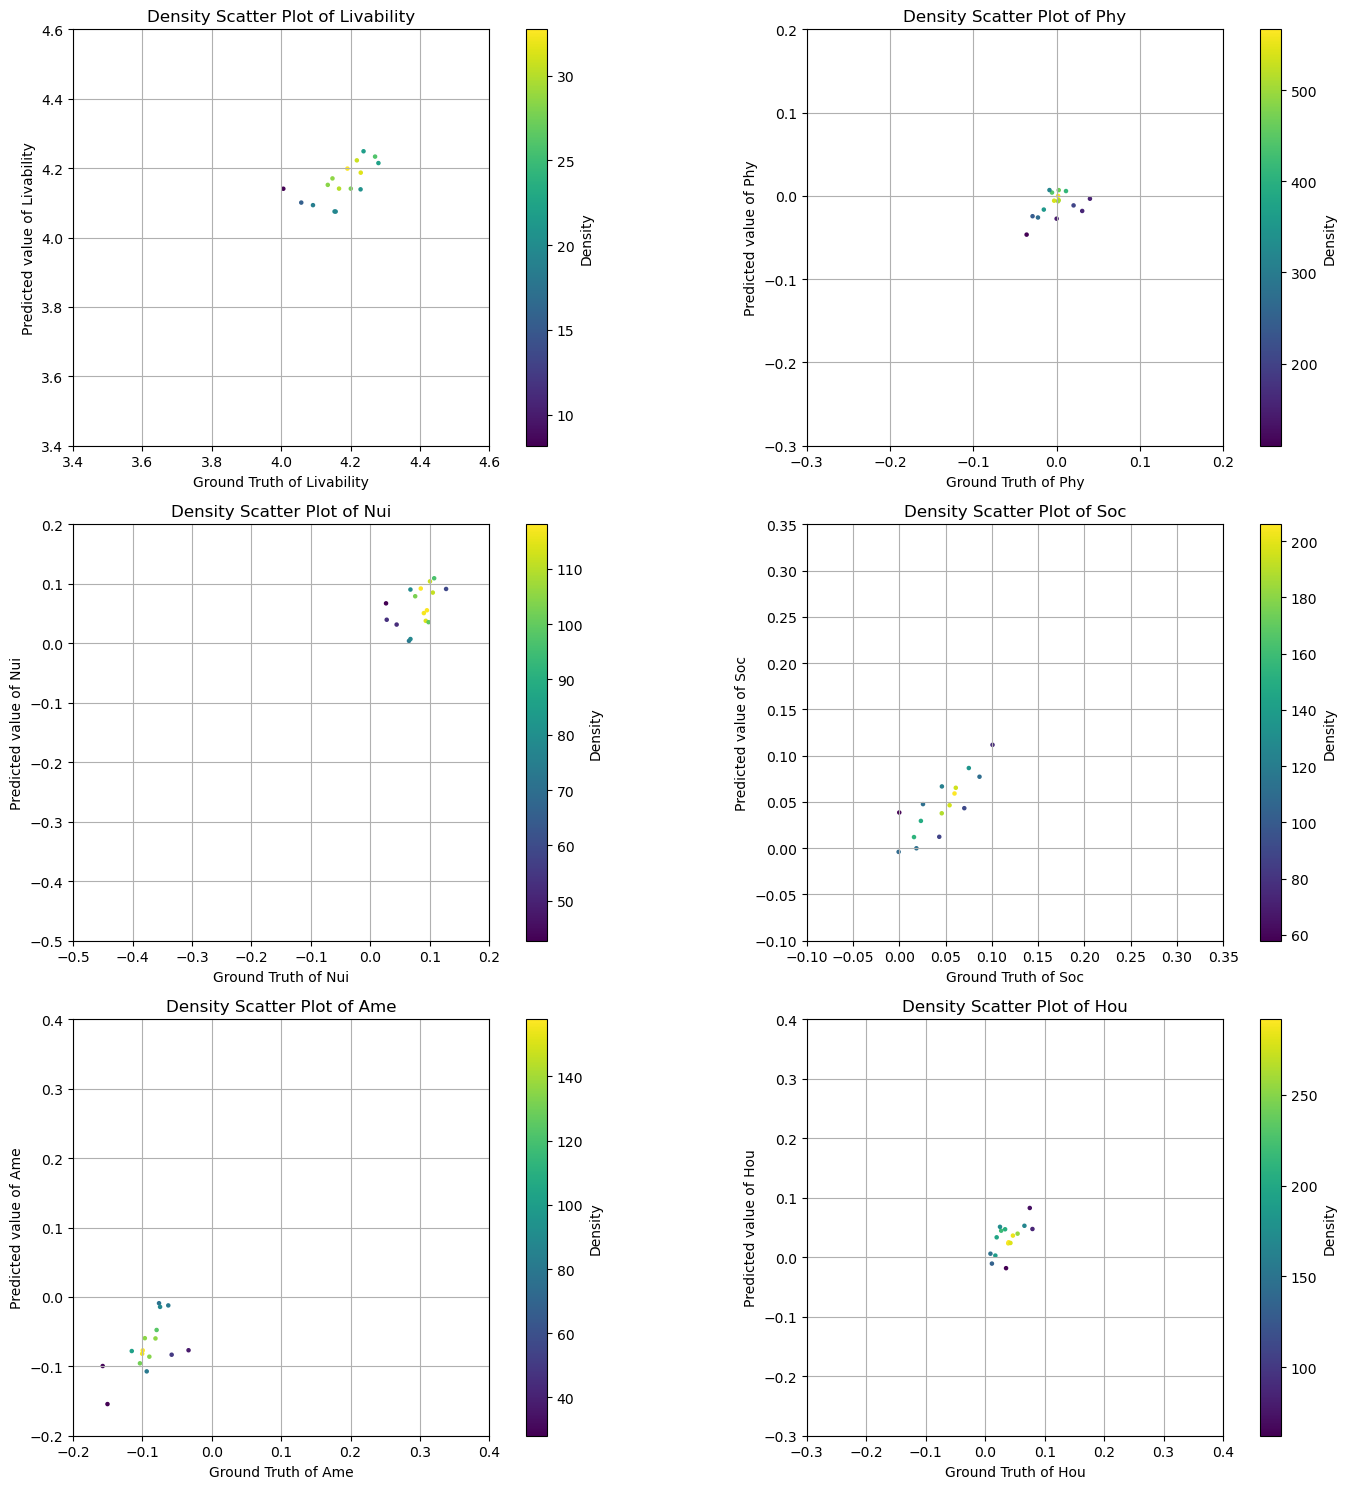

2026-08-03 20:39:27,099 - __main__ - INFO - ***** Eval results  *****
2026-08-03 20:39:27,100 - __main__ - INFO -   loss = 0.0012089525116607547
2026-08-03 20:39:27,101 - __main__ - INFO -   r_Pearson_6 = 0.9997580747966242
2026-08-03 20:39:27,102 - __main__ - INFO -   r_Pearson_fys = 0.4802824860639124
2026-08-03 20:39:27,103 - __main__ - INFO -   r_Pearson_lbm = 0.6473467584070843
2026-08-03 20:39:27,104 - __main__ - INFO -   r_Pearson_onv = 0.443544387820804
2026-08-03 20:39:27,105 - __main__ - INFO -   r_Pearson_soc = 0.8278683846818524
2026-08-03 20:39:27,105 - __main__ - INFO -   r_Pearson_vrz = 0.595919783438158
2026-08-03 20:39:27,106 - __main__ - INFO -   r_Pearson_won = 0.6460453750891753
2026-08-03 20:39:27,112 - __main__ - INFO -   r_squared_6 = tensor(0.9995)
2026-08-03 20:39:27,113 - __main__ - INFO -   r_squared_fys = tensor(-0.0996)
2026-08-03 20:39:27,115 - __main__ - INFO -   r_squared_lbm = tensor(0.3693)
2026-08-03 20:39:27,116 - __main__ - INFO -   r_squared_onv = 

Evaluation complete,Number of results: 22


dict_keys(['loss_', 'rmse_6_', 'r_squared_6_', 'r_Pearson_6_', 'rmse_lbm_', 'r_squared_lbm_', 'r_Pearson_lbm_', 'rmse_tgts_fys_', 'r_squared_fys_', 'r_Pearson_fys_', 'rmse_tgts_onv_', 'r_squared_onv_', 'r_Pearson_onv_', 'rmse_tgts_soc_', 'r_squared_soc_', 'r_Pearson_soc_', 'rmse_tgts_vrz_', 'r_squared_vrz_', 'r_Pearson_vrz_', 'rmse_tgts_won_', 'r_squared_won_', 'r_Pearson_won_'])

In [21]:
# Evaluation
results = {}
print("=== Start Model Evaluation ===")
print(f"do_eval = {args.do_eval}")
if args.do_eval:
    # Use relative paths - work from current directory
    current_dir = os.getcwd()
    print(f"📁 Current working directory: {current_dir}")
    
    # Resolve output_dir: from Hugging Face or local path
    if USE_HF_MODEL:
        import os
        os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"  # Avoid ipywidgets version mismatch in some Jupyter envs        
        # Download model from Hugging Face and use as checkpoint
        from huggingface_hub import hf_hub_download
        cache_dir = os.path.join(current_dir, "hf_model_cache")
        os.makedirs(cache_dir, exist_ok=True)
        local_dir = os.path.join(cache_dir, HF_MODEL_REPO_ID.replace("/", "_"))
        print(f"📥 Downloading model from Hugging Face: {HF_MODEL_REPO_ID}")
        for fn in ["pytorch_model.bin", "config.json"]:
            hf_hub_download(repo_id=HF_MODEL_REPO_ID, filename=fn, local_dir=local_dir, repo_type="model")
        output_dir_path = os.path.normpath(local_dir)
        print(f"📂 Using model from: {output_dir_path}")
    else:
        # Resolve output_dir - keep it relative if possible (local model)
        if os.path.isabs(args.output_dir):
            try:
                rel_path = os.path.relpath(args.output_dir, current_dir)
                if not rel_path.startswith('..'):
                    output_dir_path = os.path.join(current_dir, rel_path)
                    print(f"📂 Converted absolute path to relative: {rel_path}")
                else:
                    output_dir_path = args.output_dir
                    print(f"📂 Using absolute path: {output_dir_path}")
            except ValueError:
                output_dir_path = args.output_dir
                print(f"📂 Using absolute path: {output_dir_path}")
        else:
            output_dir_path = os.path.join(current_dir, args.output_dir)
            print(f"📂 Using relative path: {args.output_dir} -> {output_dir_path}")
        output_dir_path = os.path.normpath(output_dir_path)
     
    print(f"📂 Resolved output_dir: {output_dir_path}")
    print(f"📂 output_dir exists: {os.path.exists(output_dir_path)}")
    
    # Use resolved path for checkpoints
    checkpoints = []
    
    # Check if root output_dir has pytorch_model.bin
    root_model_path = os.path.join(output_dir_path, 'pytorch_model.bin')
    if os.path.exists(root_model_path):
        checkpoints.append(output_dir_path)
        print(f"✅ Found root model: {output_dir_path}")
    
    if args.eval_all_checkpoints:
        # Search for folders containing "checkpoint" keyword
        checkpoint_dirs = []
        if os.path.exists(output_dir_path):
            for item in os.listdir(output_dir_path):
                item_path = os.path.join(output_dir_path, item)
                if os.path.isdir(item_path) and "checkpoint" in item:
                    # Check if pytorch_model.bin exists in the directory
                    model_file = os.path.join(item_path, "pytorch_model.bin")
                    if os.path.exists(model_file):
                        checkpoint_dirs.append(item_path)
        
        if checkpoint_dirs:
            checkpoints.extend(sorted(checkpoint_dirs))
            print(f"✅ Found checkpoint folders: {checkpoint_dirs}")
        else:
            print(f"⚠️  No checkpoint folders found in: {output_dir_path}")
    
    # If no checkpoints found at all, still try to use output_dir
    if not checkpoints:
        checkpoints = [output_dir_path]
        print(f"⚠️  No models found, will try: {output_dir_path}")

    logger.info("Evaluate the following checkpoints: %s", checkpoints)
    print(f"Found {len(checkpoints)} checkpoints: {checkpoints}")

    for checkpoint in checkpoints:
        global_step = checkpoint.split("-")[-1] if len(checkpoints) > 1 else ""
        print ("global_step",global_step)        
        prefix = checkpoint.split("/")[-1] if checkpoint.find("checkpoint") != -1 else ""
        print(f"Loading model: {checkpoint}")
        model = MMBTForClassification(transformer_config, multimodal_config)
        model_path = os.path.join(checkpoint, 'pytorch_model.bin')
        print(f"Loading model file: {model_path}")
        
        # Check if file exists before loading
        if not os.path.exists(model_path):
            print(f"❌ Model file not found: {model_path}")
            print(f"   Please ensure the model is trained and saved in: {checkpoint}")
            print(f"   Current working directory: {current_dir}")
            print(f"   You may need to:")
            print(f"     1. Train the model first, or")
            print(f"     2. Download the model to: {checkpoint}")
            continue
        
        # Load state_dict and handle compatibility issues
        #state_dict = torch.load(model_path)
        # map_location: load checkpoint on CPU if no GPU (model may have been saved on CUDA)
        state_dict = torch.load(model_path, map_location=args.device)
        
        # Remove keys that may cause compatibility issues
        keys_to_remove = []
        problematic_patterns = ['position_ids', 'token_type_ids']
        
        for key in state_dict.keys():
            for pattern in problematic_patterns:
                if pattern in key and 'embeddings' in key:
                    keys_to_remove.append(key)
                    break
        
        if keys_to_remove:
            print(f"🔧 Removed {len(keys_to_remove)} incompatible keys:")
            for key in keys_to_remove:
                print(f"   - {key}")
                del state_dict[key]
        
        # Use strict=False to allow partial matching
        missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)
        
        if missing_keys:
            print(f"⚠️  Missing keys: {len(missing_keys)} ")
        if unexpected_keys:
            print(f"⚠️  Unexpected keys: {len(unexpected_keys)} ")
        
        print("✅ Model loaded")
        model.to(args.device)
        print("Starting evaluation...")
        result = evaluate(args, model, tokenizer, evaluate=True, test=True, prefix=prefix)
        print(f"Evaluation complete,Number of results: {len(result)}")
        result = dict((k + "_{}".format(global_step), v) for k, v in result.items())
        results.update(result)

results.keys()



In [22]:
print("=== Evaluation results ===")
print(f"Number of results: {len(results)}")
if results:
    print("Result details:")
    for key, value in results.items():
        print(f"  {key}: {value}")
else:
    print("NoFoundEvaluation results！")

results

=== Evaluation results ===
Number of results: 22
Result details:
  loss_: 0.0012089525116607547
  rmse_6_: 0.034769993275403976
  r_squared_6_: 0.999497652053833
  r_Pearson_6_: 0.9997580747966242
  rmse_lbm_: 0.05790559574961662
  r_squared_lbm_: 0.3693045973777771
  r_Pearson_lbm_: 0.6473467584070843
  rmse_tgts_fys_: 0.020447341725230217
  r_squared_fys_: -0.09956634044647217
  r_Pearson_fys_: 0.4802824860639124
  rmse_tgts_onv_: 0.03672696650028229
  r_squared_onv_: -0.7488555908203125
  r_Pearson_onv_: 0.443544387820804
  rmse_tgts_soc_: 0.017655113711953163
  r_squared_soc_: 0.6296720504760742
  r_Pearson_soc_: 0.8278683846818524
  rmse_tgts_vrz_: 0.03698311001062393
  r_squared_vrz_: -0.4828934669494629
  r_Pearson_vrz_: 0.595919783438158
  rmse_tgts_won_: 0.02131289429962635
  r_squared_won_: -0.05309700965881348
  r_Pearson_won_: 0.6460453750891753


{'loss_': 0.0012089525116607547,
 'rmse_6_': tensor(0.0348),
 'r_squared_6_': tensor(0.9995),
 'r_Pearson_6_': 0.9997580747966242,
 'rmse_lbm_': tensor(0.0579),
 'r_squared_lbm_': tensor(0.3693),
 'r_Pearson_lbm_': 0.6473467584070843,
 'rmse_tgts_fys_': tensor(0.0204),
 'r_squared_fys_': tensor(-0.0996),
 'r_Pearson_fys_': 0.4802824860639124,
 'rmse_tgts_onv_': tensor(0.0367),
 'r_squared_onv_': tensor(-0.7489),
 'r_Pearson_onv_': 0.443544387820804,
 'rmse_tgts_soc_': tensor(0.0177),
 'r_squared_soc_': tensor(0.6297),
 'r_Pearson_soc_': 0.8278683846818524,
 'rmse_tgts_vrz_': tensor(0.0370),
 'r_squared_vrz_': tensor(-0.4829),
 'r_Pearson_vrz_': 0.595919783438158,
 'rmse_tgts_won_': tensor(0.0213),
 'r_squared_won_': tensor(-0.0531),
 'r_Pearson_won_': 0.6460453750891753}

Available result keys: ['loss_', 'r_Pearson_6_', 'r_Pearson_fys_', 'r_Pearson_lbm_', 'r_Pearson_onv_', 'r_Pearson_soc_', 'r_Pearson_vrz_', 'r_Pearson_won_', 'r_squared_6_', 'r_squared_fys_', 'r_squared_lbm_', 'r_squared_onv_', 'r_squared_soc_', 'r_squared_vrz_', 'r_squared_won_', 'rmse_6_', 'rmse_lbm_', 'rmse_tgts_fys_', 'rmse_tgts_onv_', 'rmse_tgts_soc_', 'rmse_tgts_vrz_', 'rmse_tgts_won_']


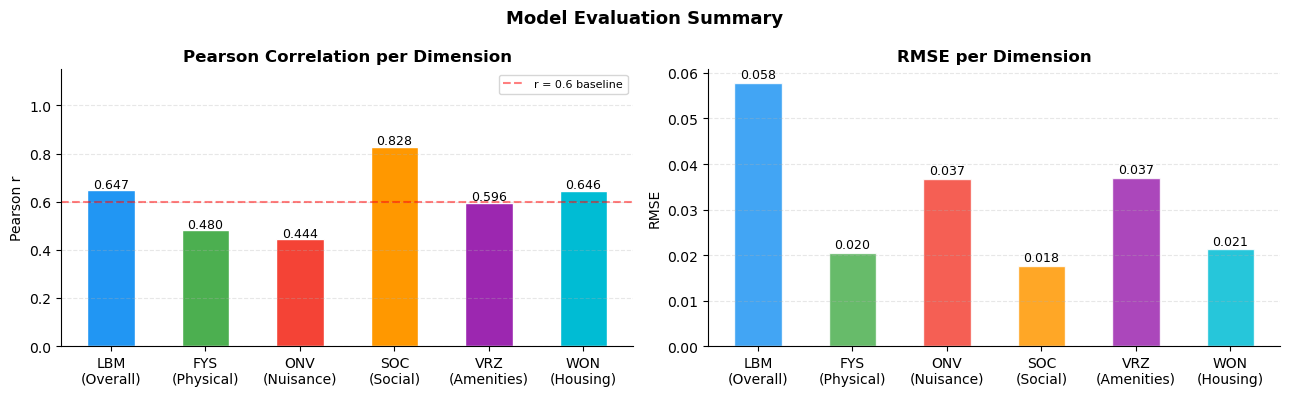

Figure saved as evaluation_summary.png

───────────────────────────────────────────────────────
Dimension                 Pearson r         RMSE
───────────────────────────────────────────────────────
LBM (Overall)                0.6473       0.0579
FYS (Physical)               0.4803       0.0204
ONV (Nuisance)               0.4435       0.0367
SOC (Social)                 0.8279       0.0177
VRZ (Amenities)              0.5959       0.0370
WON (Housing)                0.6460       0.0213
───────────────────────────────────────────────────────
Overall (all 6)              0.9998       0.0348
───────────────────────────────────────────────────────


In [23]:
"""
Visualise evaluation results: per-dimension Pearson r and RMSE bar charts.
Requires `results` dict to be populated by the evaluation cell above.

Note: the evaluate() function appends a step suffix to every key
  (e.g. "r_Pearson_lbm_" or "r_Pearson_lbm_50").
  We use prefix matching so the plots work regardless of suffix.
"""
import matplotlib.pyplot as plt

# ── Base key names (without suffix) ──────────────────────────────────────────
LABEL_DISPLAY = ['LBM\n(Overall)', 'FYS\n(Physical)', 'ONV\n(Nuisance)',
                 'SOC\n(Social)',   'VRZ\n(Amenities)', 'WON\n(Housing)']
R_BASE    = ['r_Pearson_lbm', 'r_Pearson_fys', 'r_Pearson_onv',
             'r_Pearson_soc', 'r_Pearson_vrz', 'r_Pearson_won']
RMSE_BASE = ['rmse_lbm',      'rmse_tgts_fys', 'rmse_tgts_onv',
             'rmse_tgts_soc', 'rmse_tgts_vrz', 'rmse_tgts_won']
OVERALL_R_BASE    = 'r_Pearson_6'
OVERALL_RMSE_BASE = 'rmse_6'
COLORS6 = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0', '#00BCD4']

def _find(results, base_key):
    """Return the float value for the first results key that starts with base_key."""
    for k, v in results.items():
        if k == base_key or k.startswith(base_key + "_"):
            try:
                return float(v)
            except Exception:
                return None
    return None

def plot_evaluation_summary(results):
    # Debug: show all available keys
    print("Available result keys:", sorted(results.keys()))

    r_vals    = [_find(results, b) for b in R_BASE]
    rmse_vals = [_find(results, b) for b in RMSE_BASE]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── Pearson r ──────────────────────────────────────────────────────────────
    ax = axes[0]
    valid_r = [(lbl, v, c) for lbl, v, c in zip(LABEL_DISPLAY, r_vals, COLORS6)
               if v is not None]
    if valid_r:
        lbls, vals, cols = zip(*valid_r)
        bars = ax.bar(lbls, vals, color=cols, edgecolor='white', width=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.3f}', ha='center', fontsize=9)
        ax.set_ylim(0, 1.15)
        ax.axhline(0.6, color='red', linestyle='--', alpha=0.5, label='r = 0.6 baseline')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'No Pearson r values found\n(check printed keys above)',
                ha='center', va='center', transform=ax.transAxes, color='grey')
    ax.set_ylabel('Pearson r')
    ax.set_title('Pearson Correlation per Dimension', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # ── RMSE ───────────────────────────────────────────────────────────────────
    ax = axes[1]
    valid_rmse = [(lbl, v, c) for lbl, v, c in zip(LABEL_DISPLAY, rmse_vals, COLORS6)
                  if v is not None]
    if valid_rmse:
        lbls, vals, cols = zip(*valid_rmse)
        bars = ax.bar(lbls, vals, color=cols, edgecolor='white', width=0.5, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{v:.3f}', ha='center', fontsize=9)
    else:
        ax.text(0.5, 0.5, 'No RMSE values found\n(check printed keys above)',
                ha='center', va='center', transform=ax.transAxes, color='grey')
    ax.set_ylabel('RMSE')
    ax.set_title('RMSE per Dimension', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.suptitle('Model Evaluation Summary', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('evaluation_summary.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Figure saved as evaluation_summary.png")

    # ── Summary table ──────────────────────────────────────────────────────────
    sep = '─' * 55
    print(f"\n{sep}")
    print(f"{'Dimension':<22} {'Pearson r':>12} {'RMSE':>12}")
    print(sep)
    for lbl, rb, rmse_b in zip(LABEL_DISPLAY, R_BASE, RMSE_BASE):
        r_v    = _find(results, rb)
        rmse_v = _find(results, rmse_b)
        r_str    = f'{r_v:.4f}'    if r_v    is not None else 'N/A'
        rmse_str = f'{rmse_v:.4f}' if rmse_v is not None else 'N/A'
        print(f"{lbl.replace(chr(10), ' '):<22} {r_str:>12} {rmse_str:>12}")
    print(sep)
    overall_r    = _find(results, OVERALL_R_BASE)
    overall_rmse = _find(results, OVERALL_RMSE_BASE)
    if overall_r is not None or overall_rmse is not None:
        r_s    = f'{overall_r:.4f}'    if overall_r    is not None else 'N/A'
        rmse_s = f'{overall_rmse:.4f}' if overall_rmse is not None else 'N/A'
        print(f"{'Overall (all 6)':<22} {r_s:>12} {rmse_s:>12}")
        print(sep)

if results:
    plot_evaluation_summary(results)
else:
    print("No results yet — run the evaluation cells above first.")


## Saving Test Eval Results

The code automatically saved evaluation result from each checkpoint in its respective folder. This next cell simply saves all of them in one place.

In [24]:
with open(os.path.join(args.output_dir, "final_eval_results.txt"), mode='a', encoding='utf-8') as out_f:
    print(results, file=out_f)

## 9. Cross-Modal Attention Analysis

### Background

The TMTMR model (Zhou et al., 2026) builds on the **Multimodal Bitransformer (MMBT)** architecture, which 
concatenates image-derived token embeddings and text token embeddings into a **single joint sequence** 
that is fed to a BERT-based Transformer encoder.  
As a result, every **self-attention head** in every Transformer layer can attend across *all* modalities 
simultaneously, enabling the model to discover cross-modal dependencies without any explicit alignment step.

### How Attention Weights Are Extracted

Each of the 12 Transformer layers contains 12 independent attention heads.  
For a single input sample the model returns attention tensors of shape  
`[num_layers, num_heads, seq_len, seq_len]` = `[12, 12, seq_len, seq_len]`.

The following procedure (adapted from the paper's analysis) aggregates these weights into a 
compact **per-modality attention profile**:

| Step | Operation | Output shape |
|---|---|---|
| 1 | Stack 12 layer tensors | `[12, 12, seq_len, seq_len]` |
| 2 | Sum over 12 heads (dim 1) | `[12, seq_len, seq_len]` |
| 3 | Average over destination tokens (dim 1) | `[12, seq_len]` |
| 4 | Slice modal tokens, skip `[CLS]` & `[SEP]` | `[12, 10]` (RS×3, DSM×3, SVI×3, POI×1) |
| 5 | Sum within each modality | `[12, 4]` — one column per modality |

The resulting matrix (12 layers × 4 modalities) is visualised as a heatmap, 
and a column-wise sum yields the **overall modality importance** across all layers.

### What the Results Reveal

In the paper, attention analysis shows that:

- **RS imagery** consistently receives the highest cumulative attention across layers, 
  reflecting its dominant role in capturing urban morphology and built-environment features 
  relevant to livability.
- **POI text** contributes a focused but meaningful attention signal, especially in 
  higher Transformer layers where semantic reasoning takes place.
- **DSM** and **SVI/NLRS** carry complementary structural and socioeconomic cues that 
  support finer-grained differentiation between livability aspects such as *Wonen* (residential 
  quality) and *Fysieke omgeving* (physical environment).

> **Reference:** Zhou et al. (2026), *Remote Sensing of Environment*, 334, 115232.  
> Section 4.3 — "Multimodal Attention Analysis".


In [25]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# ── Extract attention weights from one test sample ───────────────────────────
eval_dataset_attn = load_examples(tokenizer, args, evaluate=False, test=True)
from torch.utils.data import SequentialSampler, DataLoader
single_loader = DataLoader(
    eval_dataset_attn,
    sampler=SequentialSampler(eval_dataset_attn),
    batch_size=1,
    collate_fn=hf_collate_fn,
)

batch = next(iter(single_loader))
model.eval()
with torch.no_grad():
    input_ids          = batch["sentence"].to(args.device)
    input_modal        = batch["image"].to(args.device)
    modal_start_tokens = batch["image_start_token"].to(args.device)
    modal_end_tokens   = batch["image_end_token"].to(args.device)
    attention_mask = (
        batch["attention_mask"].to(args.device)
        if "attention_mask" in batch
        else torch.ones_like(input_ids).to(args.device)
    )
    outputs = model(
        input_modal,
        input_ids=input_ids,
        modal_start_tokens=modal_start_tokens,
        modal_end_tokens=modal_end_tokens,
        attention_mask=attention_mask,
        token_type_ids=None,
        modal_token_type_ids=None,
        position_ids=None,
        modal_position_ids=None,
        head_mask=None,
        inputs_embeds=None,
        labels=None,
        return_dict=True,
    )

# outputs.attentions: tuple of 12 tensors, each [1, num_heads, seq_len, seq_len]
# Squeeze batch dimension and move to CPU
attentions = [a.squeeze(0).cpu() for a in outputs.attentions]
print(f"Number of attention layers: {len(attentions)}")
print(f"Shape per layer (num_heads, seq_len, seq_len): {attentions[0].shape}")


Loading dataset 'Vinjou/Multimodal_urban_livability_evaluation_dataset' from Hugging Face... (evaluate=False, test=True)
Number of attention layers: 12
Shape per layer (num_heads, seq_len, seq_len): torch.Size([12, 12, 12])


stacked_tensor.shape torch.Size([12, 12, 12, 12])
summed_tensor.shape torch.Size([12, 12, 12])
tensor([[3.4158e+00, 1.5454e+00, 7.8889e-01, 5.2458e-01, 6.5067e-01, 2.2075e-01,
         2.6828e-01, 1.2277e+00, 4.2478e-01, 2.0770e-01, 1.1293e+00, 1.5962e+00],
        [5.5521e+00, 2.8739e-01, 2.6915e-01, 3.1416e-01, 7.0432e-02, 9.9098e-02,
         1.6939e-01, 8.8679e-02, 6.4975e-02, 1.2060e-01, 4.5757e-01, 4.5064e+00],
        [4.8643e+00, 3.2366e-01, 3.8400e-01, 4.0516e-01, 5.9764e-02, 5.7236e-02,
         1.2121e-01, 1.1735e-01, 1.2172e-01, 1.2294e-01, 6.7844e-01, 4.7442e+00],
        [1.7302e+00, 1.3202e+00, 8.7819e-01, 3.8644e-01, 1.1891e-01, 8.1444e-02,
         2.6123e-01, 1.7637e-01, 9.8195e-02, 1.3812e-01, 5.0971e+00, 1.7136e+00],
        [2.6517e-01, 1.2383e+00, 7.6491e-01, 1.9017e-01, 1.7992e-01, 6.6925e-02,
         7.1103e-02, 1.6744e-01, 1.4958e-01, 5.4308e-02, 8.5766e+00, 2.7561e-01],
        [1.1498e-01, 2.3004e-01, 1.1147e-01, 2.7160e-02, 1.0472e-01, 1.7170e-02,
         

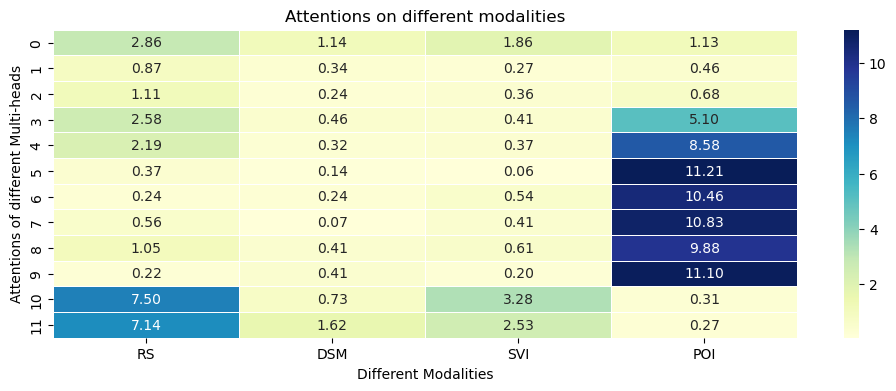

torch.Size([1, 4])


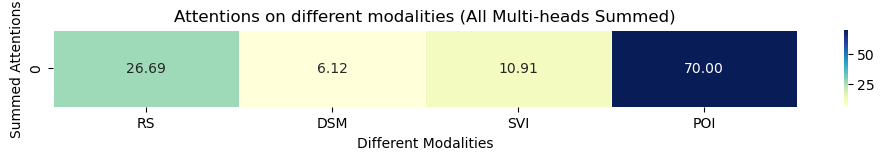

In [26]:
# ── Compute and visualise per-modality attention ────────────────────────────
# Stack 12 layers → [12, num_heads, seq_len, seq_len]
stacked_tensor = torch.stack(attentions, dim=0)
print("stacked_tensor.shape", stacked_tensor.shape)

# Sum over heads (dim=1) → [12, seq_len, seq_len]
summed_12head_tensor = stacked_tensor.sum(dim=1)
print("summed_tensor.shape", summed_12head_tensor.shape)

# Mean over destination-token positions (dim=1) → [12, seq_len]
mean_dim2 = torch.mean(summed_12head_tensor, dim=1)
print(mean_dim2)

# Remove the start token (index 0) and end token (last index);
# keep the 10 modal tokens: RS×3, DSM×3, SVI×3, POI×1
rs_dsm_svi = mean_dim2[:, 1:-1]  # shape [num_layers, 10]

# --- Aggregate sub-tokens by modality ---
sum_rs  = torch.sum(rs_dsm_svi[:, :3],  dim=1, keepdim=True)
sum_dsm = torch.sum(rs_dsm_svi[:, 3:6], dim=1, keepdim=True)
sum_svi = torch.sum(rs_dsm_svi[:, 6:9], dim=1, keepdim=True)
POI     = rs_dsm_svi[:, 9].view(-1, 1)  # convert to 2-D tensor
rs_dsm_svi_POI_4in1 = torch.cat((sum_rs, sum_dsm, sum_svi, POI), dim=1)
print(rs_dsm_svi_POI_4in1.shape)

xticklabels = ["RS", "DSM", "SVI", "POI"]

# Heatmap: attention per head × modality
plt.figure(figsize=(12, 4))
sns.heatmap(rs_dsm_svi_POI_4in1.numpy(), cmap="YlGnBu", annot=True, fmt=".2f",
            linewidths=0.5, xticklabels=xticklabels)
plt.title("Attentions on different modalities")
plt.xlabel("Different Modalities")
plt.ylabel("Attentions of different Multi-heads")
plt.show()

# Sum across all heads to get a single row
rs_dsm_poi_3in1_all_heads = torch.sum(rs_dsm_svi_POI_4in1, dim=0, keepdim=True)
print(rs_dsm_poi_3in1_all_heads.shape)

plt.figure(figsize=(12, 1))
sns.heatmap(rs_dsm_poi_3in1_all_heads.numpy(), cmap="YlGnBu", annot=True, fmt=".2f",
            linewidths=0.5, xticklabels=xticklabels)
plt.title("Attentions on different modalities (All Multi-heads Summed)")
plt.xlabel("Different Modalities")
plt.ylabel("Summed Attentions")
plt.show()


## 10. Full Grad-CAM Saliency Visualization

### Background

**Gradient-weighted Class Activation Mapping (Grad-CAM)** (Selvaraju et al., 2017) is a post-hoc 
interpretability technique that uses the gradients of a target output with respect to the 
feature maps of a chosen convolutional layer to produce a spatial saliency map.  
High-activation regions correspond to image patches that most strongly influence the model's prediction.

In the TMTMR model each image modality (RS, DSM, SVI) is independently encoded by a shared 
**DenseNet-121** backbone.  
The target layer chosen here is the *last* Conv2d inside that backbone:

```
denseblock4 → denselayer16 → conv2   (32 output channels, 7×7 spatial resolution)
```

This layer sits at the deepest semantic level of the encoder and produces feature maps that 
directly feed into the adaptive pooling step which generates the 3 image-token embeddings per modality.

### "Full" Grad-CAM vs. Standard Grad-CAM

Standard Grad-CAM applies a ReLU after combining gradients and feature maps, retaining only 
*positive* contributions.  
This notebook uses **Full Grad-CAM** (no ReLU), which preserves both positive 
(activating) and negative (suppressing) evidence:

$$\text{CAM}^c = \sum_k \underbrace{\bar{g}_k^c}_{\text{channel weight}} \cdot A^k$$

where $\bar{g}_k^c = \frac{1}{Z}\sum_{i,j}\frac{\partial y^c}{\partial A^k_{ij}}$ is the 
spatially-averaged gradient for class $c$ and channel $k$, and $A^k$ is the $k$-th feature map.

The signed map is then bilinearly upsampled to 224×224 and normalised jointly across the three 
modalities for a given output, so relative strengths are directly comparable.

### Implementation Details

Because the model jointly encodes RS, DSM, and SVI through three parallel DenseNet streams, 
a separate **forward + backward pass** is run for each livability output 
(LBM, FYS, ONV, SOC, VRZ, WON).  
Setting `retain_graph=False` (default) frees the computation graph after each backward pass, 
greatly reducing memory consumption compared to a single retained-graph strategy.

| Output | Dutch label | Livability aspect |
|---|---|---|
| LBM | Leefbaarometer | Overall livability index |
| FYS | Fysieke omgeving | Physical environment |
| ONV | Onveiligheid | Perceived safety |
| SOC | Sociale samenhang | Social cohesion |
| VRZ | Voorzieningen | Amenity provision |
| WON | Woningvoorraad | Housing stock quality |

### Interpreting the Output

- **Warm colours (red/orange)** in the overlay indicate spatial regions that *increase* the 
  predicted livability score.
- **Cool colours (blue)** indicate regions that *decrease* the score.
- Comparing the three modality columns (RS / DSM / SVI) for a given output reveals which 
  type of remote sensing information the model relies on for each livability dimension.

> **Reference:** Zhou et al. (2026), *Remote Sensing of Environment*, 334, 115232.  
> Section 4.4 — "Spatial Saliency via Grad-CAM".


GradCAM entries: ['RS_E1993N3660.tif', 'RS_E2001N3646.tif', 'RS_E2045N3662.tif', 'RS_E2014N3673.tif', 'RS_E1979N3637.tif', 'RS_E2013N3670.tif', 'RS_E2023N3660.tif', 'RS_E2041N3656.tif', 'RS_E2010N3650.tif', 'RS_E2036N3662.tif', 'RS_E2004N3641.tif', 'RS_E2044N3664.tif', 'RS_E2009N3647.tif', 'RS_E2007N3646.tif', 'RS_E2041N3663.tif', 'RS_E2041N3662.tif']
hf_rows keys: ['RS_E2041N3662.tif', 'RS_E2001N3646.tif', 'RS_E2044N3664.tif', 'RS_E2041N3656.tif', 'RS_E2036N3662.tif', 'RS_E2041N3663.tif', 'RS_E2045N3662.tif', 'RS_E2013N3670.tif', 'RS_E2014N3673.tif', 'RS_E2004N3641.tif', 'RS_E2007N3646.tif', 'RS_E2010N3650.tif', 'RS_E2023N3660.tif', 'RS_E1979N3637.tif', 'RS_E1993N3660.tif', 'RS_E2009N3647.tif']
Matched 16 / 16 samples from HuggingFace
Target: Conv2d  out_ch=32  kernel=(3, 3)

Feature: E1993N3660  |  text: 'Null'
  outputs: ['LBM', 'FYS', 'ONV', 'SOC', 'VRZ', 'WON']
  computing LBM ... done
  computing FYS ... done
  computing ONV ... done
  computing SOC ... done
  computing VRZ ... d

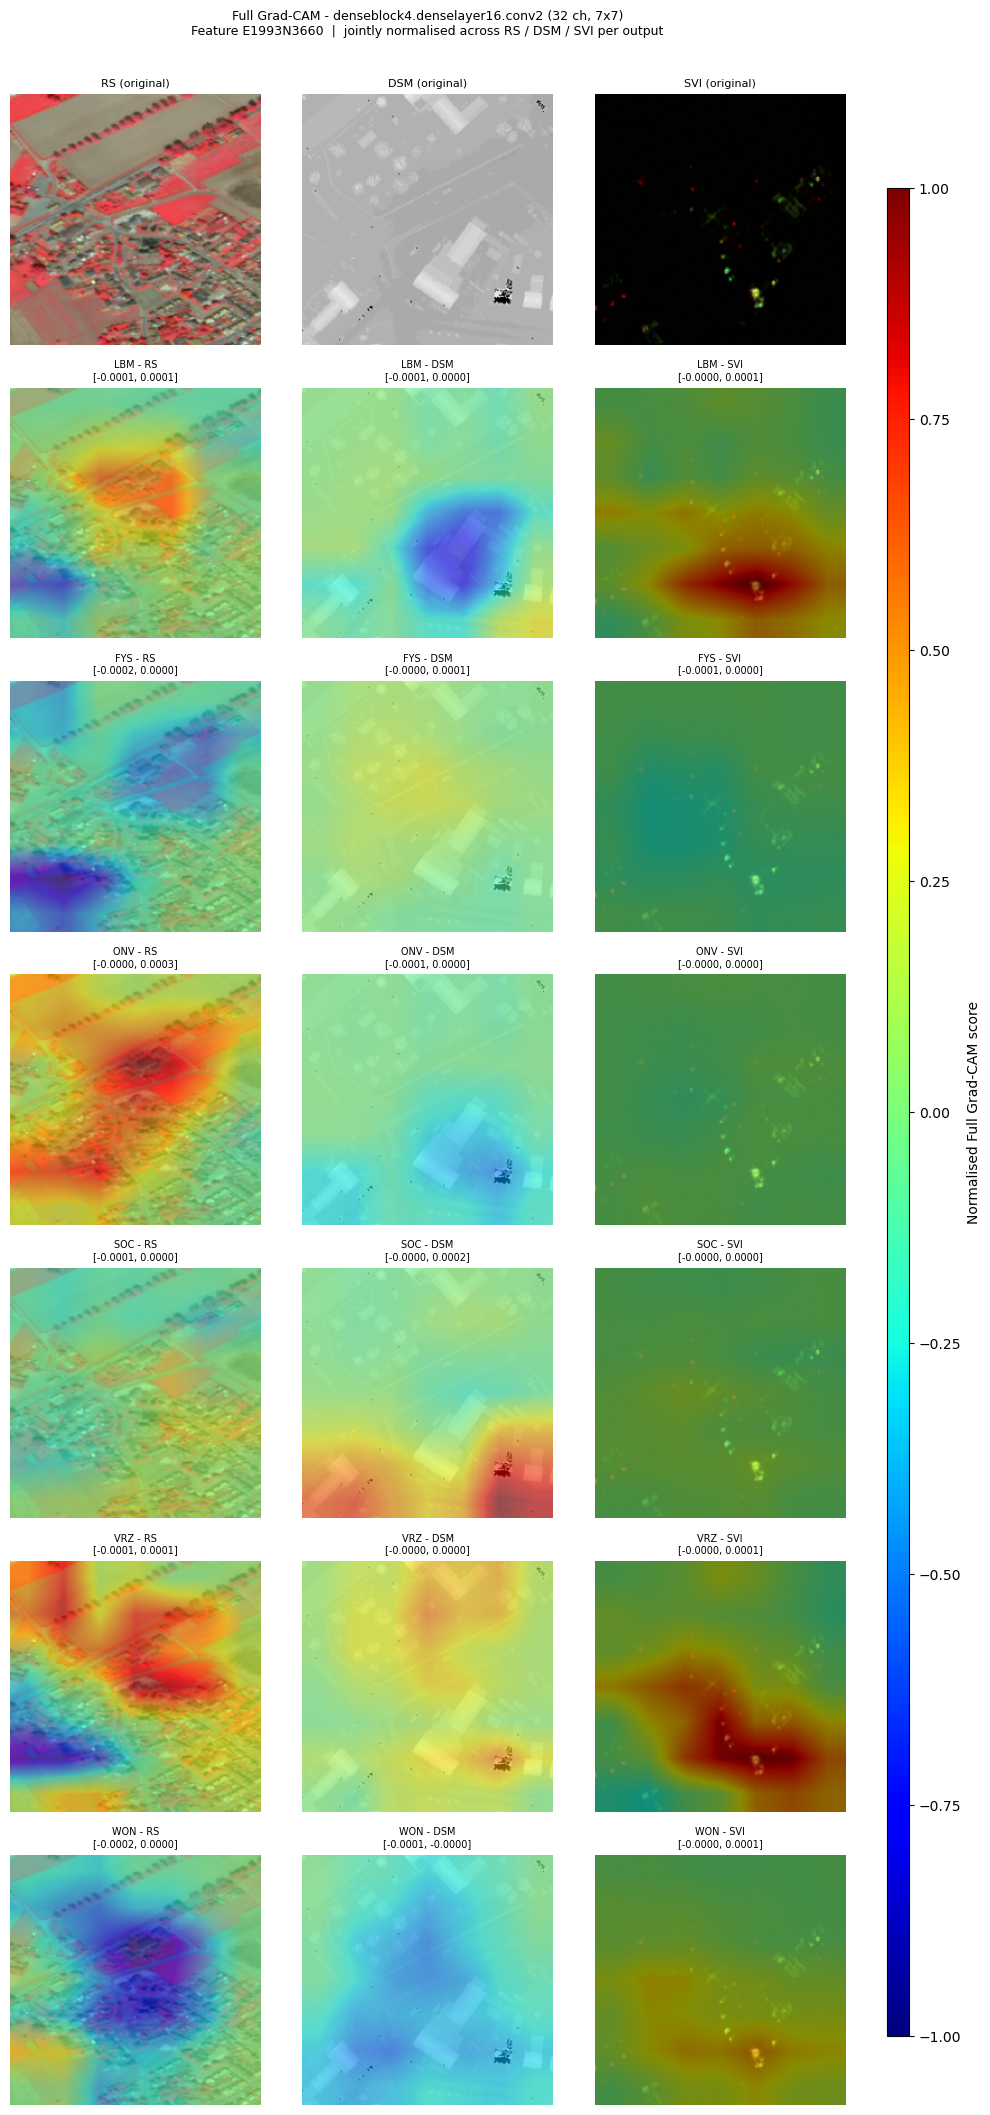

Done: E1993N3660


In [27]:
import os, json as _json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import torch, torch.nn.functional as F
from PIL import Image
from datasets import load_dataset
from huggingface_hub import HfFolder
from MMBT_liva.mmbt_utils_liva_0318 import (
    get_image_transforms, get_image_transforms_gray, get_image_transforms_giu
)

# ── Load GradCAM.json ─────────────────────────────────────────────────────────
GRADCAM_JSON = "json/Livability_test_Beesel_16samples.json"

gradcam_entries = []
with open(GRADCAM_JSON) as _f:
    for line in _f:
        line = line.strip()
        if line:
            gradcam_entries.append(_json.loads(line))

img_set     = {e['img']  for e in gradcam_entries}
id_set      = {e['id']   for e in gradcam_entries}
text_by_img = {e['img']:  e['text'] for e in gradcam_entries}
print(f"GradCAM entries: {[e['img'] for e in gradcam_entries]}")

# ── Load matching samples from HuggingFace ────────────────────────────────────
_token  = os.environ.get('HF_TOKEN') or HfFolder.get_token()
hf_full = load_dataset("Vinjou/Multimodal_urban_livability_evaluation_dataset",
                        token=_token)

# Fast lookup: fetch only the lightweight string column to find row indices,
# then use direct integer indexing (no full dataset scan / no image decoding).
# Build id→gradcam_img_key maps (handle both int and str ids in the dataset)
id_to_img     = {e['id']:      e['img'] for e in gradcam_entries}
id_to_img_str = {str(e['id']): e['img'] for e in gradcam_entries}

hf_rows = {}   # gradcam img_filename -> dataset row
for split_ds in hf_full.values():
    feats   = split_ds.features
    has_img = 'img' in feats
    has_id  = 'id'  in feats
    if not has_img and not has_id:
        continue

    # Fetch only lightweight string/int columns — no image decoding
    col_img = split_ds['img'] if has_img else [None] * len(split_ds)
    col_id  = split_ds['id']  if has_id  else [None] * len(split_ds)

    for i, (ds_img, ds_id) in enumerate(zip(col_img, col_id)):
        gradcam_key = None
        if ds_img is not None and ds_img in img_set:
            gradcam_key = ds_img                          # exact img match
        elif ds_id is not None:
            gradcam_key = (id_to_img.get(ds_id)          # int id match
                           or id_to_img_str.get(str(ds_id)))  # str id match
        if gradcam_key and gradcam_key not in hf_rows:
            hf_rows[gradcam_key] = split_ds[i]           # direct index access

    if len(hf_rows) == len(gradcam_entries):
        break  # all targets found, stop early

print(f"hf_rows keys: {list(hf_rows.keys())}")

print(f"Matched {len(hf_rows)} / {len(gradcam_entries)} samples from HuggingFace")

tf_rs  = get_image_transforms()
tf_dsm = get_image_transforms_gray()
tf_giu = get_image_transforms_giu()

OUTPUT_NAMES_ALL = ["LBM", "FYS", "ONV", "SOC", "VRZ", "WON"]
MODAL_NAMES      = ["RS", "DSM", "SVI"]

# Reduce to ["LBM"] for a quick check (6x faster)
OUTPUT_NAMES_SEL = OUTPUT_NAMES_ALL

# ── Target layer ──────────────────────────────────────────────────────────────
_encoder   = model.mmbt.modal_encoder.encoder
_tgt_layer = _encoder.model[0].denseblock4.denselayer16.conv2
print(f"Target: {_tgt_layer.__class__.__name__}  "
      f"out_ch={_tgt_layer.out_channels}  kernel={_tgt_layer.kernel_size}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def _load_sample_hf(entry, hf_row):
    rs_raw  = hf_row['rs_image'].convert('RGB')
    dsm_raw = hf_row['dsm_image'].convert('RGB')
    giu_raw = hf_row['giu_image'].convert('RGB')
    text    = entry['text']
    img_9ch = torch.cat(
        [tf_rs(rs_raw), tf_dsm(dsm_raw), tf_giu(giu_raw)], dim=0
    ).unsqueeze(0)
    toks = tokenizer.encode(text, add_special_tokens=True)
    return dict(
        img_9ch   = img_9ch,
        raw       = {'RS': rs_raw, 'DSM': dsm_raw, 'SVI': giu_raw},
        sentence  = torch.tensor([toks[1:-1]]),
        mask      = torch.ones(1, len(toks) - 2, dtype=torch.long),
        start_tok = torch.tensor([toks[0]]),
        end_tok   = torch.tensor([toks[-1]]),
    )


def _gradcam_one_output(sample, tgt_layer, out_idx):
    feature_maps = []
    def _hook_fn(m, inp, out):
        out.retain_grad()
        feature_maps.append(out)
    hook = tgt_layer.register_forward_hook(_hook_fn)
    t   = sample['img_9ch'].to(args.device)
    ids = sample['sentence'].to(args.device)
    ms  = sample['start_tok'].to(args.device)
    me  = sample['end_tok'].to(args.device)
    msk = sample['mask'].to(args.device)
    model.eval()
    with torch.enable_grad():
        model.zero_grad()
        outputs = model(
            t, input_ids=ids,
            modal_start_tokens=ms, modal_end_tokens=me,
            attention_mask=msk,
            token_type_ids=None, modal_token_type_ids=None,
            position_ids=None,   modal_position_ids=None,
            head_mask=None,      inputs_embeds=None,
            labels=None,         return_dict=True,
        )
        hook.remove()
        outputs.logits[:, out_idx].sum().backward()
    modal_cams = {}
    for m_idx, m_name in enumerate(MODAL_NAMES):
        fm   = feature_maps[m_idx]
        grad = fm.grad
        if grad is None:
            modal_cams[m_name] = np.zeros((224, 224))
        else:
            weights = grad.detach().mean(dim=[2, 3], keepdim=True)
            cam = (weights * fm.detach()).sum(dim=1, keepdim=True)   # no ReLU
            cam = F.interpolate(cam, size=(224, 224),
                                mode='bilinear', align_corners=False)
            modal_cams[m_name] = cam.squeeze().cpu().numpy()
    return modal_cams


def _compute_full_gradcams(sample, tgt_layer, out_names):
    results = {}
    for out_name in out_names:
        out_idx = OUTPUT_NAMES_ALL.index(out_name)
        print(f"  computing {out_name} ...", end=" ", flush=True)
        results[out_name] = _gradcam_one_output(sample, tgt_layer, out_idx)
        print("done")
    return results


def _to_display(raw_pil):
    arr = np.array(raw_pil.resize((224, 224))).astype(np.float32)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    a_min, a_max = arr.min(), arr.max()
    return (arr - a_min) / (a_max - a_min + 1e-8)

def _overlay(ax, raw_pil, cam_norm, title, alpha=0.55):
    orig    = _to_display(raw_pil)
    heatmap = mpl_cm.jet((cam_norm + 1.0) / 2.0)[..., :3]
    blended = np.clip(alpha * heatmap + (1 - alpha) * orig, 0, 1)
    ax.imshow(blended)
    ax.set_title(title, fontsize=7)
    ax.axis('off')


# ── Main loop over GradCAM.json entries ──────────────────────────────────────
n_rows = 1 + len(OUTPUT_NAMES_SEL)

for entry in gradcam_entries[:1]:  # only first entry in GradCAM.json
    img_key = entry['img']
    fid     = img_key.replace('RS_', '').replace('.tif', '')  # e.g. 'E1069N4252'

    if img_key not in hf_rows:
        print(f"Warning: {img_key} not found in HuggingFace dataset, skipping.")
        continue

    print(f"\n{'='*60}")
    print(f"Feature: {fid}  |  text: {entry['text'][:60]!r}")
    print(f"  outputs: {OUTPUT_NAMES_SEL}")

    sample   = _load_sample_hf(entry, hf_rows[img_key])
    all_cams = _compute_full_gradcams(sample, _tgt_layer, OUTPUT_NAMES_SEL)

    header = f"{'Output':<8}" + "".join(f"  {m:>28}" for m in MODAL_NAMES)
    print(header)
    print('-' * len(header))
    for out_name in OUTPUT_NAMES_SEL:
        row_str = f"{out_name:<8}"
        for m in MODAL_NAMES:
            c = all_cams[out_name][m]
            row_str += f"  [{c.min():.4f}, {c.max():.4f}]{' ':>12}"
        print(row_str)

    fig, axes = plt.subplots(n_rows, 3, figsize=(9, 3 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(
        f"Full Grad-CAM - denseblock4.denselayer16.conv2 (32 ch, 7x7)\n"
        f"Feature {fid}  |  jointly normalised across RS / DSM / SVI per output",
        fontsize=9, y=1.005
    )

    for col, m_name in enumerate(MODAL_NAMES):
        axes[0, col].imshow(_to_display(sample['raw'][m_name]))
        axes[0, col].set_title(f"{m_name} (original)", fontsize=8)
        axes[0, col].axis('off')

    for row, out_name in enumerate(OUTPUT_NAMES_SEL, start=1):
        raw_cams  = [all_cams[out_name][m] for m in MODAL_NAMES]
        scale     = max(max(abs(c.min()), abs(c.max())) for c in raw_cams) + 1e-8
        norm_cams = [c / scale for c in raw_cams]
        for col, (m_name, cam_n) in enumerate(zip(MODAL_NAMES, norm_cams)):
            c_raw = raw_cams[col]
            _overlay(axes[row, col], sample['raw'][m_name], cam_n,
                     f"{out_name} - {m_name}\n[{c_raw.min():.4f}, {c_raw.max():.4f}]")

    cbar_ax = fig.add_axes([1.01, 0.04, 0.025, 0.88])
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(vmin=-1, vmax=1))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label="Normalised Full Grad-CAM score")
    plt.tight_layout()
    plt.show()
    print(f"Done: {fid}")


## 11. Conclusion

This study demonstrates that urban livability can be
predicted **directly** from multiple geospatial data sources and types using a deep learning
approach.

### Main conclusions

1. **Synergistic multimodal evaluation.** The TMTMR model uses pretrained state-of-the-art
   computer vision (DenseNet-121) and natural language processing (multilingual BERT)
   components to extract features from RS images, DSM, NLRS images and POI data, enabling a
   comprehensive and synergistic evaluation of urban livability.

2. **Attention makes fusion adaptive.** By incorporating an attention mechanism, the model
   dynamically assigns varying importance to features from different modalities. This captures
   intrinsic information and interrelationships among the modalities, rather than treating
   them as independent feature blocks — and it is what makes the joint token sequence
   (Section 4.3) more than a concatenation.

3. **Overall modality ranking: RS > NLRS > DSM > POI.** RS images contribute most to the
   overall livability score, followed by NLRS images, DSM, and POI data. This ranking aligns
   with the observed information gain and is confirmed independently by the attention analysis
   in Section 9.

4. **Modality importance is domain-specific.** NLRS images play a **dominant role in evaluating
   PHY (physical environment) and AME (amenities)**, while RS images are more influential for
   the other three domains. Each modality therefore has a tailored utility — a single global
   ranking would hide this, which is precisely why the per-domain Grad-CAM comparison in
   Section 10 is worth running.

5. **Multi-task beats single-task.** By leveraging shared and cross-domain correlations,
   multi-task learning outperforms single-task learning for both overall livability and the
   domain-specific scores.

Together these findings show that the TMTMR model is an **efficient and scalable** approach for
evaluating urban livability directly from multimodal geospatial data, with significant
implications for urban planning and policy-making.

### Limitations and future work

While TMTMR performs strongly across most tasks, accuracy for the **NUI** and **AME** domain
scores was slightly lower than expected. Modelling these domains appears more challenging,
potentially due to the specific characteristics of the data or the complexities inherent in
those aspects of livability. Notably, although NLRS images contribute substantially to PHY and
AME, other domains may require different or additional data sources.

Planned directions:

- **New data sources** — in particular the recently released **Satellite Embedding V1** dataset
  generated by AlphaEarth Foundations (Brown et al., 2025), a global AI-generated geospatial
  dataset from Google and DeepMind.
- **Foundation models** — evaluating emerging geospatial foundation models such as **TerraMind**
  (Jakubik et al., 2025) and **Prithvi** (Szwarcman et al., 2025), alongside advanced feature
  extraction and fusion strategies and novel network architectures better suited to the more
  challenging domains.
- **Geographic transfer** — assessing the model's scalability and efficiency in other regions
  once corresponding livability labels become available.

### Reusing this notebook

| Goal | What to change |
|---|---|
| Reproduce the results | Run with `do_train = False`, `USE_HF_MODEL = True` |
| Apply to your own region | Rewrite `HFDatasetWrapper` (Section 6) to serve your rasters, POI string and labels; change `model_name` if your text is not Dutch/English |
| Add a fifth modality | Encode it, project to 768-d, append to the sequence, and increase `num_image_embeds` |

All components are openly available: the notebook on the
[I-GUIDE Platform](https://platform.i-guide.io/notebooks/f856fc6e-9537-4d74-b6f0-dd64881dff28), the model and dataset on Hugging Face.